# CISC839 — Assignment 2
## Regression Analysis for Review Effort: Human vs. Agentic PRs

---
**Name:** Mahmoud Alyosify | **ID:** 20595453  
**Course:** CISC 839 Topics in Information Systems W26


---

### The Question
> Are Pull Requests authored by AI coding agents associated with **higher or lower review effort** compared with human-authored PRs?

### Notebook Structure
| Block | Description |
|-------|-------------|
| 1 | Load AIDev tables |
| 2 | Feature Engineering (TTR, churn, path flags, CDI, RICR) |
| 3 | Dataset Assembly |
| 4 | Preprocessing & Cleaning |
| 5 | Descriptive Statistics & Hypothesis Tests |
| 6 | Assumption Checking (VIF, BP, Shapiro, DW) |
| 7 | Model Fitting (OLS, Logistic, Agentic Deep-Dive) |
| 8 | Visualisations |
| 9 | RESULTS SUMMARY |

---


---
## Imports & Global Configuration

In [1]:
import re, warnings, sys
from pathlib import Path
from datetime import datetime

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import mannwhitneyu

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

import matplotlib, matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# ── Global styling
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.12)
plt.rcParams.update({"figure.dpi": 150, "savefig.bbox": "tight"})
matplotlib.rcParams["axes.spines.top"]   = False
matplotlib.rcParams["axes.spines.right"] = False

# ── Global constants
OUTPUT_DIR     = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

STAR_THRESHOLD = 100   # Min repo stars --> filters out toy/inactive repos
TTR_CAP_HOURS  = 8_760 # Cap = 1 year --> prevents extreme outliers from dominating (365*24=8760)
SEED           = 42
np.random.seed(SEED)

# ── Plot colour palette
_P = {0: "#1565C0", 1: "#BF360C"}
_L = {0: "Human",   1: "Agentic"}

print("✓ Imports complete")

✓ Imports complete


---
## Block 1 — Load AIDev Tables

**Design decision:** I load 6 tables from the AIDev dataset stored as `.parquet` files.  
| Table | Description |
|-------|-------------|
| `agentic_pull_requests` | PRs authored by AI coding agents (e.g., Devin, GitHub Copilot Workspace) |
| `human_pull_requests` | PRs authored by human developers |
| `repositories` | Repo metadata (stars, language, contributors) |
| `pr_reviews` | Review comments and reviewer metadata |
| `pr_commit_details` | Per-commit line additions/deletions and file paths |
| `human_pr_task_type` | Pre-labeled task categories for human PRs |


In [2]:
def load_data_hf() -> dict:
    print("━" * 65)
    print("BLOCK 1 ▸ Loading AIDev tables from Hugging Face")
    print("━" * 65)
    base = "hf://datasets/hao-li/AIDev"
    files = {
        "agentic_pull_requests": "pull_request.parquet",
        "human_pull_requests": "human_pull_request.parquet",
        "human_pr_task_type": "human_pr_task_type.parquet",
        "repositories": "repository.parquet",
        "pr_reviews": "pr_reviews.parquet",
        "pr_commit_details": "pr_commit_details.parquet",
    }
    tables = {}
    for name, file in files.items():
        path = f"{base}/{file}"

        try:
            df = pd.read_parquet(path)
            print(f"✓ {name:<50s} {len(df):>10,} rows × {df.shape[1]} cols")
            tables[name] = df

        except Exception as e:
            print(f"{name:<50s} [ERROR: {e}]")
            tables[name] = None

    return tables
tables = load_data_hf()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 1 ▸ Loading AIDev tables from Hugging Face
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✓ agentic_pull_requests                                  33,596 rows × 14 cols
✓ human_pull_requests                                     6,618 rows × 13 cols
✓ human_pr_task_type                                      6,618 rows × 6 cols
✓ repositories                                            2,807 rows × 7 cols
✓ pr_reviews                                             28,875 rows × 7 cols
✓ pr_commit_details                                     711,923 rows × 14 cols


---
## Block 2 — Feature Engineering

### Why these specific features?

| Feature | Rationale | Source of inspiration |
|---------|-----------|----------------------|
| **TTR** (Time-to-Resolution) | Primary proxy for review effort — hours from PR creation to close/merge | Standard in SE research |
| **log_churn** | PR size confounds review effort; larger PRs take longer by default | *More Code, Less Reuse* |
| **touches_cicd** | CI/CD changes demand extra scrutiny → known to inflate review time | *When AI Agents Touch CI/CD* |
| **includes_tests** | Test presence signals code confidence → may reduce review rounds | *Testing with AI Agents* |
| **log_body_length / is_silent** | PR description quality affects how fast reviewers understand intent | *Silent Pull Requests* |
| **CDI** (Cognitive Dispersion Index) | Unique reviewers / total review events — measures review distribution | Novel engineering |

**Task type labelling strategy (hybrid):** Human PRs use the curated `human_pr_task_type` table (LLM-classified with reasoning), while agentic PRs use regex inference on the PR title (no task table available for agentic PRs in AIDev).
| **RICR** (Rework-to-Initial Churn Ratio) | Corrective commits after first submission → signals instability | Novel engineering |

In [3]:
# 2.1  Outcome: TTR
#I use the time something is merged or closed as the time it is fixed.
def compute_ttr(df: pd.DataFrame) -> pd.Series:
    """Hours from created_at min(merged_at, closed_at). Positive only."""
    c  = pd.to_datetime(df["created_at"], utc=True, errors="coerce")
    m  = pd.to_datetime(df["merged_at"],  utc=True, errors="coerce")
    cl = pd.to_datetime(df["closed_at"],  utc=True, errors="coerce")
    resolved = m.combine_first(cl)
    ttr = (resolved - c).dt.total_seconds() / 3600.0
    return ttr.where(ttr > 0).clip(upper=TTR_CAP_HOURS)

# ── 2.2  Outcome: Merge rate
def compute_merged(df: pd.DataFrame) -> pd.Series:
    return pd.to_datetime(df["merged_at"], utc=True, errors="coerce").notna().astype(int)
print("TTR and merge functions defined")

TTR and merge functions defined


In [4]:
# ── 2.3  Repo join
#   - Agentic table has repo_id (integer) → join by ID
#   - Human table has repo_url (string)   → join by URL
# I build both indexes from the repos table so each half can join correctly.

def build_repo_lookup(repos: pd.DataFrame) -> pd.DataFrame:
    """FIX: star col is 'stars', NOT 'stargazers_count'."""
    r = repos.copy()
    r["id_str"]  = r["id"].astype(str)
    r["url_str"] = r["url"].str.strip()
    return r

def get_repo_meta(pr_df: pd.DataFrame,
                  repo_lkp: pd.DataFrame,
                  join_on: str = "id") -> pd.DataFrame:
    """Returns repo_stars and repo_lang aligned to pr_df index."""
    out = pd.DataFrame(index=pr_df.index)

    if join_on == "id":
        key = pr_df["repo_id"].astype(str)
        lkp = repo_lkp.set_index("id_str")[["stars", "language"]]
    else:
        key = pr_df["repo_url"].str.strip()
        lkp = repo_lkp.set_index("url_str")[["stars", "language"]]

    meta = lkp.reindex(key.values)
    out["repo_stars"] = meta["stars"].values
    out["repo_lang"]  = meta["language"].fillna("unknown").values
    return out
print("Repo join functions defined")

Repo join functions defined


In [5]:
# ── 2.4  Churn from pr_commit_details
def build_pr_churn(pr_commit_details: pd.DataFrame) -> pd.DataFrame:
    pcd = pr_commit_details.copy()
    adds = pd.to_numeric(pcd["commit_stats_additions"], errors="coerce").fillna(0).clip(0)
    dels = pd.to_numeric(pcd["commit_stats_deletions"], errors="coerce").fillna(0).clip(0)
    pcd["_adds"] = adds
    pcd["_dels"] = dels

    grp = pcd.groupby("pr_id")
    out = pd.DataFrame({
        "total_additions": grp["_adds"].sum(),
        "total_deletions": grp["_dels"].sum(),
        "n_commits":       grp["sha"].count() if "sha" in pcd.columns else grp["_adds"].count(),
        "n_files":         grp["filename"].nunique() if "filename" in pcd.columns else 0,
    })
    out["total_churn"] = out["total_additions"] + out["total_deletions"]
    return out
print("Churn aggregation function defined")

Churn aggregation function defined


In [6]:
# ── 2.5  Path flags
CICD_RE = re.compile(
    r"(\.github/workflows|\.travis\.yml|Jenkinsfile|\.circleci|"
    r"Makefile|docker-compose|Dockerfile|\.gitlab-ci\.yml|azure-pipelines)",
    re.IGNORECASE,
)
TEST_RE = re.compile(
    r"(test/|tests/|spec/|__tests__/|\.test\.|\.spec\.|_test\.)",
    re.IGNORECASE,
)

def build_path_flags(pr_commit_details: pd.DataFrame) -> pd.DataFrame:
    if "filename" not in pr_commit_details.columns:
        return pd.DataFrame(columns=["touches_cicd", "includes_tests"])

    pcd = pr_commit_details[["pr_id", "filename"]].dropna(subset=["filename"])
    grp = pcd.groupby("pr_id")["filename"].apply(
        lambda s: " ||| ".join(s.astype(str))
    )
    out = pd.DataFrame(index=grp.index)
    out["touches_cicd"]  = grp.str.contains(CICD_RE, regex=True).astype(int)
    out["includes_tests"] = grp.str.contains(TEST_RE,  regex=True).astype(int)
    return out


print("✓ Path flag functions defined")

✓ Path flag functions defined


In [7]:
# ── 2.6  PR Description Features

def body_features(body_col: pd.Series) -> pd.DataFrame:
    body = body_col.fillna("")
    wc   = body.str.split().str.len().fillna(0).astype(int)
    return pd.DataFrame({
        "log_body_length": np.log1p(wc),
        "is_silent":       (body.str.strip().str.len() < 10).astype(int),
    }, index=body_col.index)


print("✓ Body feature function defined")

✓ Body feature function defined


In [8]:
# ── 2.7  CDI & RICR (agentic-only novel metrics)
def compute_cdi(pr_reviews: pd.DataFrame) -> pd.Series:
    grp = pr_reviews.groupby("pr_id")["user"]
    return (grp.nunique() / grp.count()).clip(0, 1).rename("cdi")
# RICR = Rework-to-Initial Churn Ratio
# Formula: Σ churn(commits 2..N) / churn(commit 1)  — capped at 10
def compute_ricr(pr_commit_details: pd.DataFrame) -> pd.Series:
    pcd = pr_commit_details.copy()
    pcd["churn"] = (
        pd.to_numeric(pcd["commit_stats_additions"], errors="coerce").fillna(0)
      + pd.to_numeric(pcd["commit_stats_deletions"], errors="coerce").fillna(0)
    ).clip(lower=0)
    pcd = pcd.sort_values(["pr_id", "sha"])
    first = pcd.groupby("pr_id")["churn"].first()
    total = pcd.groupby("pr_id")["churn"].sum()
    return ((total - first) / first.replace(0, np.nan)).clip(0, 10).rename("ricr")


print("✓ CDI & RICR functions defined")

✓ CDI & RICR functions defined


In [9]:
# ── 2.8  Task Type — Hybrid Strategy
TASK_LABEL_MAP = {
    "feat":     "feature",
    "feature":  "feature",
    "fix":      "fix",
    "bug":      "fix",
    "refactor": "refactor",
    "perf":     "refactor",
    "docs":     "docs",
    "test":     "test",
    "chore":    "chore",
    "ci":       "chore",
    "build":    "chore",
}

TASK_RE_MAP = {
    "fix":      r"\b(fix|bug|patch|hotfix|repair|resolve|defect)\b",
    "feature":  r"\b(feat|feature|add|implement|new|introduce|support)\b",
    "refactor": r"\b(refactor|clean|simplify|reorgani[sz]e|restructure)\b",
    "docs":     r"\b(doc|docs|documentation|readme|comment|changelog)\b",
    "test":     r"\b(test|spec|coverage|unittest|pytest|tdd)\b",
    "chore":    r"\b(chore|update|bump|upgrade|dependency|deps|ci|cd)\b",
}

def infer_task_type(title: pd.Series) -> pd.Series:
    """Regex-based task inference — used for agentic PRs only."""
    t = title.fillna("").str.lower()
    out = pd.Series("other", index=title.index)
    for label, pat in reversed(list(TASK_RE_MAP.items())):
        out[t.str.contains(pat, regex=True, na=False)] = label
    return out


def task_type_from_table(pr_ids: pd.Series,
                         task_table: pd.DataFrame) -> pd.Series:
    """
    Look up curated task labels from human_pr_task_type table.
    Falls back to 'other' for unmatched IDs.
    Normalises labels via TASK_LABEL_MAP.
    """
    if task_table is None or task_table.empty:
        return pd.Series("other", index=pr_ids.index)

    # Build id → normalised label lookup
    lkp = (
        task_table[["id", "type"]]
        .dropna(subset=["type"])
        .copy()
    )
    lkp["type_norm"] = (
        lkp["type"].str.lower().str.strip()
        .map(TASK_LABEL_MAP)
        .fillna("other")
    )
    lkp = lkp.set_index("id")["type_norm"]

    result = pr_ids.map(lkp).fillna("other")
    result.index = pr_ids.index
    return result


print("Hybrid task type functions defined")
print("Human PRs --> human_pr_task_type table (curated)")
print("Agentic PRs --> regex on title (fallback)")


Hybrid task type functions defined
Human PRs --> human_pr_task_type table (curated)
Agentic PRs --> regex on title (fallback)


---
## Block 3 — Dataset Assembly

We build two half-DataFrames (agentic + human) and concatenate them.

**Key design choices:**
- **Star filter (≥100):** Filters out inactive/toy repos that may have artificially fast TTR (no real reviewers).
- **Asymmetric join for churn:** `pr_commit_details` only contains agentic PR data in AIDev → human churn is `NaN` and median-imputed in Block 4. This is acknowledged as a limitation.
- **CDI/RICR agentic-only:** These metrics require review event data (`pr_reviews`) which is only linked to agentic PRs, enabling a deep-dive in Model 3.

In [10]:
def build_dataset(tables: dict) -> pd.DataFrame:
    print("\n" + "━" * 65)
    print("BLOCK 3 ▸  Assembling feature matrix")
    print("━" * 65)

    repos    = tables["repositories"]
    ag       = tables["agentic_pull_requests"]
    hu       = tables["human_pull_requests"]
    hu_tasks = tables.get("human_pr_task_type")
    rev      = tables["pr_reviews"]
    pcd      = tables["pr_commit_details"]

    # ── Repo lookup
    repo_lkp   = build_repo_lookup(repos)
    valid_ids  = set(repo_lkp.loc[repo_lkp["stars"] >= STAR_THRESHOLD, "id_str"])
    valid_urls = set(repo_lkp.loc[repo_lkp["stars"] >= STAR_THRESHOLD, "url_str"])
    print(f"  Repos ≥{STAR_THRESHOLD} stars: {len(valid_ids):,}")

    # ── Star filter
    ag = ag[ag["repo_id"].astype(str).isin(valid_ids)].copy()
    hu = hu[hu["repo_url"].str.strip().isin(valid_urls)].copy()
    print(f"  Agentic after star filter: {len(ag):,}")
    print(f"  Human   after star filter: {len(hu):,}")

    # ── Pre-aggregate features
    print("  Aggregating churn from pr_commit_details …")
    pr_churn   = build_pr_churn(pcd)      # indexed by pr_id
    path_flags = build_path_flags(pcd)    # indexed by pr_id
    cdi        = compute_cdi(rev)         # indexed by pr_id
    ricr       = compute_ricr(pcd)        # indexed by pr_id
    print(f"  Churn aggregated for {len(pr_churn):,} PRs")
    print(f"  Path flags computed for {len(path_flags):,} PRs")

    # ── Build halves
    def _half(df: pd.DataFrame, flag: int, repo_join: str,
              task_table=None) -> pd.DataFrame:
        out = pd.DataFrame()
        out["pr_id"]      = df["id"].values
        out["is_agentic"] = flag
        out["ttr"]        = compute_ttr(df).values
        out["merged"]     = compute_merged(df).values

        repo_meta = get_repo_meta(df, repo_lkp, join_on=repo_join)
        out["repo_stars"] = repo_meta["repo_stars"].values
        out["repo_lang"]  = repo_meta["repo_lang"].values
        out["log_stars"]  = np.log1p(
            pd.to_numeric(out["repo_stars"], errors="coerce").fillna(0)
        )

        bd = body_features(df["body"])
        out["log_body_length"] = bd["log_body_length"].values
        out["is_silent"]       = bd["is_silent"].values

        if task_table is not None:
            out["task_type"] = task_type_from_table(
                df["id"], task_table
            ).values
            n_matched = (out["task_type"] != "other").sum()
            print(f"    task_type from table: {n_matched:,}/{len(out):,} "
                  f"matched ({n_matched/len(out)*100:.1f}%)")
        else:
            out["task_type"] = infer_task_type(df["title"]).values

        return out.reset_index(drop=True)

    df_a = _half(ag, 1, "id")
    df_h = _half(hu, 0, "url", task_table=hu_tasks)
    df   = pd.concat([df_a, df_h], ignore_index=True)

    # ── Join commit/review features (agentic only)
    df = df.merge(pr_churn[["total_churn", "n_commits", "n_files"]],
                  left_on="pr_id", right_index=True, how="left")
    df = df.merge(path_flags, left_on="pr_id", right_index=True, how="left")
    df = df.merge(cdi,        left_on="pr_id", right_index=True, how="left")
    df = df.merge(ricr,       left_on="pr_id", right_index=True, how="left")

    for c in ["touches_cicd", "includes_tests", "cdi", "ricr"]:
        if c not in df.columns:
            df[c] = np.nan

    print(f"\n  Combined rows (before TTR filter): {len(df):,}")

    # ── Sanity check merge rate
    mr_a = df[df.is_agentic==1]["merged"].mean()
    mr_h = df[df.is_agentic==0]["merged"].mean()
    print(f"  Merge rate — Agentic: {mr_a:.3f}   Human: {mr_h:.3f}")
    if mr_a == 0 and mr_h == 0:
        print("MERGE STILL 0 — check merged_at column manually")

    return df
df_raw = build_dataset(tables)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 3 ▸  Assembling feature matrix
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Repos ≥100 stars: 2,807
  Agentic after star filter: 33,596
  Human   after star filter: 6,569
  Aggregating churn from pr_commit_details …
  Churn aggregated for 33,580 PRs
  Path flags computed for 33,105 PRs
    task_type from table: 6,395/6,569 matched (97.4%)

  Combined rows (before TTR filter): 40,165
  Merge rate — Agentic: 0.715   Human: 0.768


---
## Block 4 — Preprocessing

### Cleaning pipeline (in order):

1. **Drop open PRs** (`ttr = NaN`) — these are censored; including them would artificially reduce TTR estimates.
2. **Log-transform TTR** — `log(1+ttr)` normalises the heavy right-skewed distribution. Required for OLS normality assumption.
3. **Winsorise** at 1st/99th percentile — removes extreme outliers without deleting rows.
4. **Log-transform churn features** — same rationale: right-skewed count data.
5. **Task type dummies** — reference category = `other` (dropped).
6. **Language dummies** — top-10 languages; `unknown` dropped to prevent collinearity with `is_agentic`.
7. **Median imputation** — fills NaN in human churn columns. Acknowledged as a limitation.

In [11]:
def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    print("\n" + "━" * 65)
    print("BLOCK 4 ▸  Preprocessing")
    print("━" * 65)

    # Step 1: Drop open PRs (TTR = NaN → no resolution timestamp)
    df = df.dropna(subset=["ttr"]).copy()
    print(f"  After dropping open PRs     : {len(df):>10,}")

    # Step 2 & 3: Log-transform TTR + winsorise at [1%, 99%]
    df["log_ttr"] = np.log1p(df["ttr"])
    p1, p99 = df["log_ttr"].quantile([0.01, 0.99])
    df["log_ttr"] = df["log_ttr"].clip(p1, p99)
    print(f"  log_ttr range: [{p1:.3f}, {p99:.3f}]")

    # Step 4: Log-transform churn features
    for raw, log_col in [("total_churn","log_churn"), ("n_files","log_files"),
                          ("n_commits","log_commits")]:
        if raw in df.columns:
            df[log_col] = np.log1p(pd.to_numeric(df[raw], errors="coerce").fillna(0))

    # Step 5: Task type dummies (reference = 'other')
    td = pd.get_dummies(df["task_type"], prefix="task")
    td.drop(columns=["task_other"], errors="ignore", inplace=True)
    df = pd.concat([df, td], axis=1)

    # Step 6: Language dummies (top-10; drop 'unknown' to avoid is_agentic collinearity)
    top10 = df["repo_lang"].value_counts().head(10).index.tolist()
    df["repo_lang_grp"] = df["repo_lang"].where(df["repo_lang"].isin(top10), "other_lang")
    ld = pd.get_dummies(df["repo_lang_grp"], prefix="lang", drop_first=True)
    ld.drop(columns=[c for c in ld.columns if "unknown" in c.lower()],
            errors="ignore", inplace=True)
    df = pd.concat([df, ld], axis=1)

    # Step 7: Handle missing values — safe group-aware median imputation
    churn_cols = [c for c in ["log_churn", "log_files", "log_commits"]
                  if c in df.columns]
    for c in churn_cols:
        agentic_median = df.loc[df.is_agentic == 1, c].median()
        df[c] = df[c].fillna(agentic_median)
    num_cols = df.select_dtypes(include=[np.number]).columns
    for c in num_cols:
        if df[c].isna().any():
            df[c] = df[c].fillna(df[c].median())

    ag_n = (df.is_agentic==1).sum()
    hu_n = (df.is_agentic==0).sum()
    mr_a = df[df.is_agentic==1]["merged"].mean()
    mr_h = df[df.is_agentic==0]["merged"].mean()
    print(f"  Final: {len(df):,}  (Agentic={ag_n:,}, Human={hu_n:,})")
    print(f"  Merge rate → Agentic: {mr_a:.3f}   Human: {mr_h:.3f}")

    return df
df = preprocess(df_raw)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 4 ▸  Preprocessing
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  After dropping open PRs     :     37,387
  log_ttr range: [0.002, 6.845]
  Final: 37,387  (Agentic=31,284, Human=6,103)
  Merge rate → Agentic: 0.768   Human: 0.826


---
## Block 5 — Descriptive Statistics & Hypothesis Tests

Before fitting any model, we examine the raw difference in TTR between groups.  
We use **two complementary tests** because:
- **Welch's t-test** — valid when group variances differ (likely here); parametric
- **Mann-Whitney U** — non-parametric; valid even if distributions are non-normal

> H₁ (directional): μ_agentic < μ_human  → Agentic PRs resolve *faster*

In [12]:
def descriptives(df: pd.DataFrame):
    print("\n" + "━" * 65)
    print("BLOCK 5a ▸  Descriptive Statistics")
    print("━" * 65)
    cols = [c for c in ["log_ttr","merged","log_churn","log_files",
                         "log_body_length","is_silent","cdi","ricr"]
            if c in df.columns]
    tbl = df.groupby("is_agentic")[cols].agg(["mean","median","std"])
    tbl.index = tbl.index.map({0:"Human",1:"Agentic"})
    print(tbl.round(3).to_string())
    return tbl
desc_tbl = descriptives(df)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 5a ▸  Descriptive Statistics
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
           log_ttr               merged               log_churn               log_files               log_body_length               is_silent                  cdi                 ricr              
              mean median    std   mean median    std      mean median    std      mean median    std            mean median    std      mean median    std   mean median    std   mean median    std
is_agentic                                                                                                                                                                                           
Human        2.322  1.854  2.046  0.826    1.0  0.379     0.000  0.000  0.000     0.000  0.000  0.000           3.691  4.127  2.083     0.157    0.0  0.364  1.000    1.0  0.000  3.000    3.0  0.000
Agentic      1.230  0.115  1.875  0.768 

In [13]:
def hypothesis_tests(df: pd.DataFrame) -> dict:
    print("\n" + "━" * 65)
    print("BLOCK 5b ▸  Hypothesis Tests")
    print("━" * 65)

    a = df[df.is_agentic==1]["log_ttr"].dropna()
    h = df[df.is_agentic==0]["log_ttr"].dropna()
# Welch's t-test: one-tailed H1: agentic < human
    t, p2 = stats.ttest_ind(a, h, equal_var=False)
    p1    = p2/2 if t < 0 else 1 - p2/2
# Mann-Whitney U: non-parametric equivalent
    u, p_mwu = mannwhitneyu(a, h, alternative="less")
    r_mwu    = 1 - 2*u/(len(a)*len(h))
# Cohen's d
    d = (a.mean()-h.mean()) / np.sqrt((a.std()**2+h.std()**2)/2)

    print(f"  n_agentic={len(a):,}   n_human={len(h):,}")
    print(f"  Mean log(1+TTR):  Agentic={a.mean():.4f}   Human={h.mean():.4f}")
    print(f"  Δ (log scale)  = {a.mean()-h.mean():.4f}")
    print(f"\n  H₁: μ_agentic < μ_human  (Agentic resolves FASTER)")
    print(f"  Welch's t      : t={t:+.4f}   p(one-tail)={p1:.6f}   Cohen's d={d:.4f}")
    print(f"  Mann-Whitney U : U={u:.0f}   p={p_mwu:.6f}   r={r_mwu:.4f}")

    return dict(t=t, p1=p1, d=d, U=u, p_mwu=p_mwu, r_mwu=r_mwu,
                mean_a=a.mean(), mean_h=h.mean(), n_a=len(a), n_h=len(h))
hyp = hypothesis_tests(df)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 5b ▸  Hypothesis Tests
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  n_agentic=31,284   n_human=6,103
  Mean log(1+TTR):  Agentic=1.2297   Human=2.3222
  Δ (log scale)  = -1.0925

  H₁: μ_agentic < μ_human  (Agentic resolves FASTER)
  Welch's t      : t=-38.6692   p(one-tail)=0.000000   Cohen's d=-0.5567
  Mann-Whitney U : U=55112708   p=0.000000   r=0.4227


---
## Block 6 — Assumption Checking

OLS regression requires:

| Assumption | Test used | What we do if violated |
|-----------|-----------|------------------------|
| No multicollinearity | VIF | Drop or combine correlated predictors |
| Homoscedasticity | Breusch-Pagan | Use **HC3 robust standard errors** |
| Normality of residuals | Shapiro-Wilk | Log-transform outcome; large N → CLT |
| No serial correlation | Durbin-Watson | Note if violated (no temporal structure assumed) |

**Why HC3 and not HC1/HC2?**  
HC3 is most conservative and performs best in finite samples with leverage points — preferred for heterogeneous observational data.

In [14]:
def compute_vif(X: pd.DataFrame) -> pd.DataFrame:
    """
    VIF computed on CONTROL variables only (is_agentic excluded).
    WHY: We want to know if control variables are collinear with each other.
    Including the treatment variable (is_agentic) in VIF would be misleading
    because some controls differ systematically between groups by design.
    """
    ctrl = [c for c in X.columns
            if c != "is_agentic" and X[c].std() > 1e-9]
    if len(ctrl) < 2:
        return pd.DataFrame({"Feature": ctrl, "VIF": [np.nan]*len(ctrl)})

    Xc  = X[ctrl].astype(float)
    vif = pd.DataFrame({
        "Feature": ctrl,
        "VIF":     [variance_inflation_factor(Xc.values, i)
                    for i in range(Xc.shape[1])],
    })
    vif["Status"] = vif.VIF.apply(
        lambda v: "⚠ SEVERE" if v>10 else ("△ MOD" if v>5 else "✓ OK"))
    return vif.sort_values("VIF", ascending=False).reset_index(drop=True)


def check_assumptions(model, label: str) -> dict:
    print(f"\n  [{label}] Assumption checks:")

# Breusch-Pagan test for heteroscedasticity
    _, bp_p, _, _ = het_breuschpagan(model.resid, model.model.exog)

# Durbin-Watson: 2.0 = no autocorrelation; < 1.5 or > 2.5 = concern
    dw_val = durbin_watson(model.resid)

# Shapiro-Wilk on a sample (max 5000 rows — SW not valid for large N)
    samp   = model.resid.sample(min(5000, len(model.resid)), random_state=SEED)
    sw_w, sw_p = stats.shapiro(samp)

    print(f"    Breusch-Pagan  p={bp_p:.4f}  → "
          f"{'HC3 SEs JUSTIFIED' if bp_p<0.05 else 'homoscedastic'}")
    print(f"    Shapiro-Wilk   W={sw_w:.4f}  p={sw_p:.4f}")
    print(f"    Durbin-Watson  {dw_val:.4f}  "
          f"({'OK' if 1.5<dw_val<2.5 else 'possible serial corr.'})")

    return dict(bp_p=bp_p, sw_p=sw_p, dw=dw_val)
print("Assumption checking functions defined")

Assumption checking functions defined


---
## Block 7 — Model Fitting

### Model Overview

| Model | Outcome | Method | Purpose |
|-------|---------|--------|---------|
| **Model 1** | log(1+TTR) | OLS + HC3 | Main analysis: does `is_agentic` affect resolution time? |
| **Model 2** | merged (0/1) | Logistic | Does `is_agentic` affect *acceptance* rate? |
| **Model 3** | log(1+TTR) | OLS + HC3 (agentic only) | Deep-dive: what drives review effort *within* agentic PRs? |

### Why OLS with log-transform instead of Negative Binomial?
- TTR is **continuous** (hours), not a count — Negative Binomial is for integer counts.
- After `log(1+TTR)`, residuals are approximately normal → OLS assumptions hold.
- HC3 standard errors correct for the remaining heteroscedasticity.
- Coefficients on `is_agentic` are interpretable as **percentage change**: `(exp(β)−1)×100%`.

In [15]:
def _pred_cols(df: pd.DataFrame, extras: list | None = None) -> list:
    """
    Builds the predictor list dynamically.
    Only includes columns that exist AND have non-zero variance.
    WHY: Zero-variance columns cause perfect multicollinearity and OLS failure.
    """
    base  = ["is_agentic"]
    ctrl  = ["log_body_length", "is_silent", "log_stars"]
    for c in ["log_churn", "log_files", "log_commits"]:
        if c in df.columns and df[c].std() > 1e-9:
            ctrl.append(c)

    tasks = [c for c in df.columns if c.startswith("task_")]
    langs = [c for c in df.columns
             if c.startswith("lang_") and "unknown" not in c.lower()]

    cols = base + ctrl + tasks + langs + (extras or [])
    return [c for c in dict.fromkeys(cols)
            if c in df.columns and pd.api.types.is_numeric_dtype(df[c]) and df[c].std() > 1e-9]


print("✓ Predictor column builder defined")

✓ Predictor column builder defined


In [16]:
# ── Model 1: OLS on log(1+TTR) with HC3

def fit_ols_ttr(df: pd.DataFrame, extra_cols=None):
    print("\n" + "━" * 65)
    print("BLOCK 7a ▸  Model 1: OLS on log(1+TTR)  [HC3 SEs]")
    print("━" * 65)
    cols  = _pred_cols(df, extra_cols)
    X     = sm.add_constant(df[cols].astype(float))
    y     = df["log_ttr"].astype(float)
    mask  = X.notna().all(1) & y.notna()
    model = sm.OLS(y[mask], X[mask]).fit(cov_type="HC3")

    b   = model.params.get("is_agentic", np.nan)
    ci  = model.conf_int()
    p   = model.pvalues.get("is_agentic", np.nan)
    pct = (np.exp(b)-1)*100
    sig = "***" if p<0.001 else ("**" if p<0.01 else ("*" if p<0.05 else "n.s."))

    print(f"  N={int(model.nobs):,}  R²={model.rsquared:.4f}  "
          f"Adj-R²={model.rsquared_adj:.4f}  AIC={model.aic:.1f}")
    print(f"\n  ┌─ is_agentic ─────────────────────────────────")
    print(f"  │  β  = {b:+.4f}  {sig}")
    if "is_agentic" in ci.index:
        print(f"  │  CI₉₅ = [{ci.loc['is_agentic',0]:+.4f}, {ci.loc['is_agentic',1]:+.4f}]")
    print(f"  │  p   = {p:.4f}")
    print(f"  │  Back-transform: {pct:+.1f}% change in TTR")
    print(f"  └──────────────────────────────────────────────")
    return model, cols
y_r  = df["log_ttr"].astype(float)
X_r  = sm.add_constant(df[["is_agentic"]].astype(float))
m_r  = sm.OLS(y_r, X_r).fit(cov_type="HC3")
print(f"  Restricted (is_agentic only): R²={m_r.rsquared:.4f}  AIC={m_r.aic:.1f}")

ols_m, ols_cols = fit_ols_ttr(df)

print(f"\n  ΔR²  = {ols_m.rsquared - m_r.rsquared:+.4f}")
print(f"  ΔAIC = {m_r.aic - ols_m.aic:+.1f}  (>0 → full model preferred)")

  Restricted (is_agentic only): R²=0.0430  AIC=154261.3

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 7a ▸  Model 1: OLS on log(1+TTR)  [HC3 SEs]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  N=37,387  R²=0.3154  Adj-R²=0.3150  AIC=141783.8

  ┌─ is_agentic ─────────────────────────────────
  │  β  = -1.4769  ***
  │  CI₉₅ = [-1.5550, -1.3987]
  │  p   = 0.0000
  │  Back-transform: -77.2% change in TTR
  └──────────────────────────────────────────────

  ΔR²  = +0.2724
  ΔAIC = +12477.5  (>0 → full model preferred)


In [17]:
# ── Model 2: Logistic on merge rate

def fit_logit_merge(df: pd.DataFrame, extra_cols=None):
    print("\n" + "━" * 65)
    print("BLOCK 7b ▸  Model 2: Logistic Regression on Merge Rate")
    print("━" * 65)

    mr_a = df[df.is_agentic==1]["merged"].mean()
    mr_h = df[df.is_agentic==0]["merged"].mean()
    print(f"  Merge rate — Agentic: {mr_a:.4f}   Human: {mr_h:.4f}")

    if mr_a == 0 or mr_h == 0:
        print("  ⚠ SKIP: No outcome variance — Logistic undefined.")
        return None, []

    cols  = _pred_cols(df, extra_cols)
    X     = sm.add_constant(df[cols].astype(float))
    y     = df["merged"].astype(int)
    mask  = X.notna().all(1) & y.notna()
    model = sm.Logit(y[mask], X[mask]).fit(method="bfgs", maxiter=1000, disp=False)
    converged = getattr(model, 'mle_retvals', {}).get('converged', None)
    if converged is False:
        print("  ⚠ WARNING: Logistic regression did NOT converge — results unreliable")
    elif converged is True:
        print("  ✓ Convergence confirmed")

    b     = model.params.get("is_agentic", np.nan)
    p     = model.pvalues.get("is_agentic", np.nan)
    ci    = model.conf_int()
    OR    = np.exp(b)
    OR_lo = np.exp(ci.loc["is_agentic",0]) if "is_agentic" in ci.index else np.nan
    OR_hi = np.exp(ci.loc["is_agentic",1]) if "is_agentic" in ci.index else np.nan
    sig   = "***" if p<0.001 else ("**" if p<0.01 else ("*" if p<0.05 else "n.s."))

    print(f"  N={int(model.nobs):,}  Pseudo-R²={model.prsquared:.4f}")
    print(f"  is_agentic  OR={OR:.4f} [{OR_lo:.4f}, {OR_hi:.4f}]  p={p:.4f}  {sig}")
    return model, cols


logit_m, _ = fit_logit_merge(df)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 7b ▸  Model 2: Logistic Regression on Merge Rate
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Merge rate — Agentic: 0.7676   Human: 0.8265
  ✓ Convergence confirmed
  N=37,387  Pseudo-R²=0.0948
  is_agentic  OR=0.4094 [0.3681, 0.4553]  p=0.0000  ***


In [18]:
# ── Model 3: Agentic-only deep-dive
def fit_agentic_deepdive(df: pd.DataFrame):
    print("\n" + "━" * 65)
    print("BLOCK 7c ▸  Model 3: Agentic-Only Deep-Dive  [CDI + RICR + Path Flags]")
    print("━" * 65)

    ag = df[df.is_agentic==1].copy()
    deep_vars = [c for c in ["cdi","ricr","touches_cicd","includes_tests"]
                 if c in ag.columns and ag[c].std() > 1e-9]
    base_ctrl = [c for c in ["log_body_length","is_silent","log_stars",
                               "log_churn","log_files","log_commits"]
                 if c in ag.columns and ag[c].std() > 1e-9]
    tasks = [c for c in ag.columns if c.startswith("task_")]

    cols  = list(dict.fromkeys(deep_vars + base_ctrl + tasks))
    cols  = [c for c in cols if pd.api.types.is_numeric_dtype(ag[c]) and ag[c].std() > 1e-9]
    X     = sm.add_constant(ag[cols].astype(float))
    y     = ag["log_ttr"].astype(float)
    mask  = X.notna().all(1) & y.notna()
    model = sm.OLS(y[mask], X[mask]).fit(cov_type="HC3")

    print(f"  N={int(model.nobs):,}  R²={model.rsquared:.4f}")
    for v in deep_vars:
        if v in model.params:
            p   = model.pvalues[v]
            sig = "***" if p<0.001 else ("**" if p<0.01 else ("*" if p<0.05 else "n.s."))
            print(f"  {v:<22s} β={model.params[v]:+.4f}  p={p:.4f}  {sig}")
    return model, cols
ag_m, _ = fit_agentic_deepdive(df)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 7c ▸  Model 3: Agentic-Only Deep-Dive  [CDI + RICR + Path Flags]
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  N=31,284  R²=0.3220
  cdi                    β=-1.1687  p=0.0000  ***
  ricr                   β=-0.0266  p=0.0000  ***
  touches_cicd           β=+0.3117  p=0.0000  ***
  includes_tests         β=-0.1747  p=0.0000  ***


In [19]:
print("\n" + "━"*65)
print("BLOCK 6 ▸  VIF (control vars only; is_agentic excluded)")
ctrl_only = [c for c in ols_cols if c != "is_agentic"]
vif_df    = compute_vif(df[ctrl_only])
print(vif_df.to_string(index=False))
assump = check_assumptions(ols_m, "OLS log(1+TTR)")


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
BLOCK 6 ▸  VIF (control vars only; is_agentic excluded)
        Feature       VIF   Status
    log_commits 72.613225 ⚠ SEVERE
      log_files 68.574180 ⚠ SEVERE
      log_churn 22.666742 ⚠ SEVERE
log_body_length 16.720780 ⚠ SEVERE
      log_stars 16.138376 ⚠ SEVERE
        lang_Go  3.827271     ✓ OK
lang_TypeScript  3.810009     ✓ OK
    lang_Python  3.261506     ✓ OK
   task_feature  2.684858     ✓ OK
       task_fix  2.132911     ✓ OK
lang_other_lang  1.849538     ✓ OK
      is_silent  1.646668     ✓ OK
     task_chore  1.547653     ✓ OK
      lang_Rust  1.420957     ✓ OK
      lang_Java  1.331585     ✓ OK
lang_JavaScript  1.298374     ✓ OK
      task_docs  1.237020     ✓ OK
      lang_Ruby  1.216760     ✓ OK
  task_refactor  1.177749     ✓ OK
      lang_HTML  1.167700     ✓ OK
       lang_C++  1.147700     ✓ OK
      task_test  1.086338     ✓ OK

  [OLS log(1+TTR)] Assumption checks:
    Breusch-Pagan  p=0.0000  → HC

---
## Block 8 — Visualisations

  ✓ outputs/fig1_ttr_merge.png


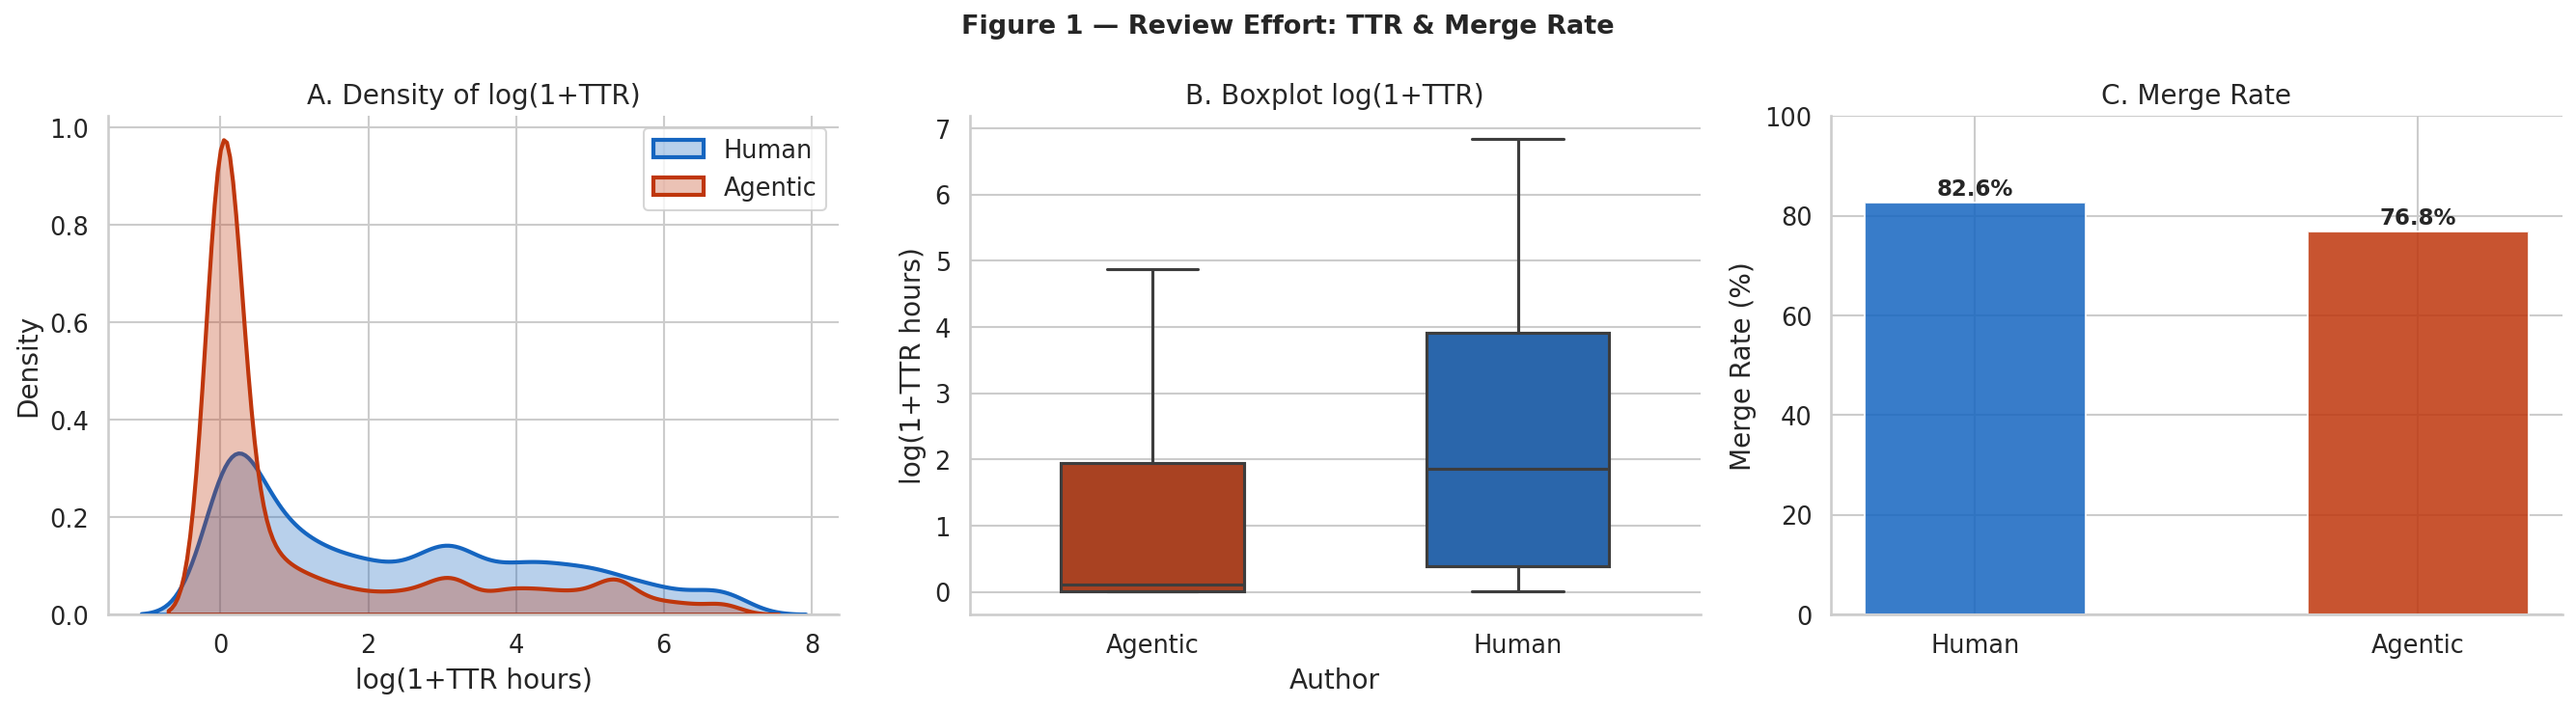

In [20]:
def fig1_ttr_merge(df: pd.DataFrame):
    """Fig 1: TTR density, boxplot, merge rate side-by-side."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Figure 1 — Review Effort: TTR & Merge Rate",
                 fontsize=13, fontweight="bold")

    # Panel A: KDE density of log(1+TTR)
    ax = axes[0]
    for flag, grp in df.groupby("is_agentic"):
        sns.kdeplot(grp["log_ttr"], ax=ax, label=_L[flag],
                    color=_P[flag], fill=True, alpha=0.30, linewidth=2)
    ax.set_title("A. Density of log(1+TTR)")
    ax.set_xlabel("log(1+TTR hours)"); ax.set_ylabel("Density"); ax.legend()

    # Panel B: Boxplot (outliers suppressed — already winsorised)
    ax = axes[1]
    tmp = df[["log_ttr","is_agentic"]].copy()
    tmp["Author"] = tmp["is_agentic"].map(_L)
    sns.boxplot(data=tmp, x="Author", y="log_ttr", ax=ax,
                palette={v:_P[k] for k,v in _L.items()},
                width=0.5, showfliers=False, linewidth=1.5)
    ax.set_title("B. Boxplot log(1+TTR)"); ax.set_ylabel("log(1+TTR hours)")

    # Panel C: Merge rate bar chart
    ax = axes[2]
    mr = df.groupby("is_agentic")["merged"].mean().reset_index()
    mr["Author"] = mr["is_agentic"].map(_L)
    bars = ax.bar(mr["Author"], mr["merged"]*100,
                  color=[_P[r] for r in mr["is_agentic"]], width=0.5, alpha=0.85)
    for bar, v in zip(bars, mr["merged"]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f"{v*100:.1f}%", ha="center", va="bottom", fontweight="bold", fontsize=11)
    ax.set_ylim(0, 100); ax.set_ylabel("Merge Rate (%)"); ax.set_title("C. Merge Rate")

    plt.tight_layout()
    p = OUTPUT_DIR / "fig1_ttr_merge.png"
    plt.savefig(p); print(f"  ✓ {p}"); plt.show()


fig1_ttr_merge(df)

  ✓ outputs/fig2_control_vars.png


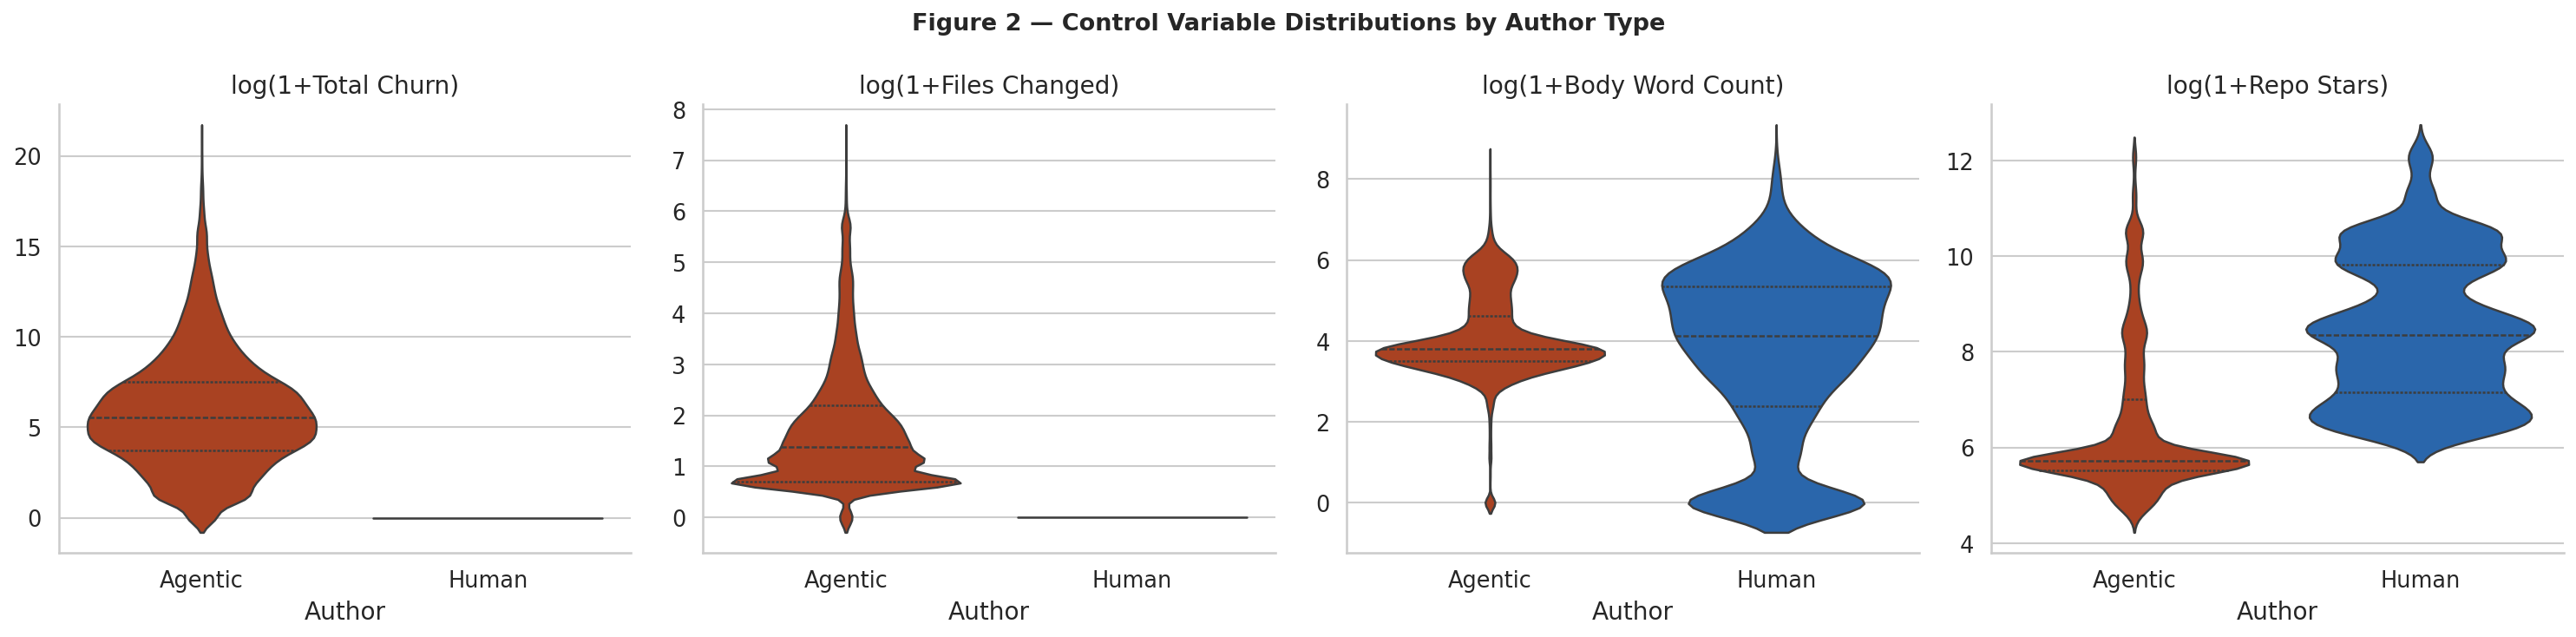

In [21]:
def fig2_controls(df: pd.DataFrame):
    """Fig 2: Violin plots of control variable distributions by author type."""
    candidates = [
        ("log_churn",       "log(1+Total Churn)"),
        ("log_files",       "log(1+Files Changed)"),
        ("log_body_length", "log(1+Body Word Count)"),
        ("log_stars",       "log(1+Repo Stars)"),
    ]
    valid = [(c,l) for c,l in candidates
             if c in df.columns and df[c].std() > 1e-9]
    if not valid:
        print("No non-zero control vars — skipping fig2"); return

    n = len(valid)
    fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
    if n == 1: axes = [axes]
    fig.suptitle("Figure 2 — Control Variable Distributions by Author Type",
                 fontsize=13, fontweight="bold")

    for ax, (col, label) in zip(axes, valid):
        tmp = df[[col,"is_agentic"]].copy()
        tmp["Author"] = tmp["is_agentic"].map(_L)
        sns.violinplot(data=tmp, x="Author", y=col, ax=ax,
                       palette={v:_P[k] for k,v in _L.items()},
                       inner="quartile", linewidth=1.2)
        ax.set_title(label); ax.set_ylabel("")

    plt.tight_layout()
    p = OUTPUT_DIR / "fig2_control_vars.png"
    plt.savefig(p); print(f"  ✓ {p}"); plt.show()


fig2_controls(df)

  ✓ outputs/fig3_vif.png


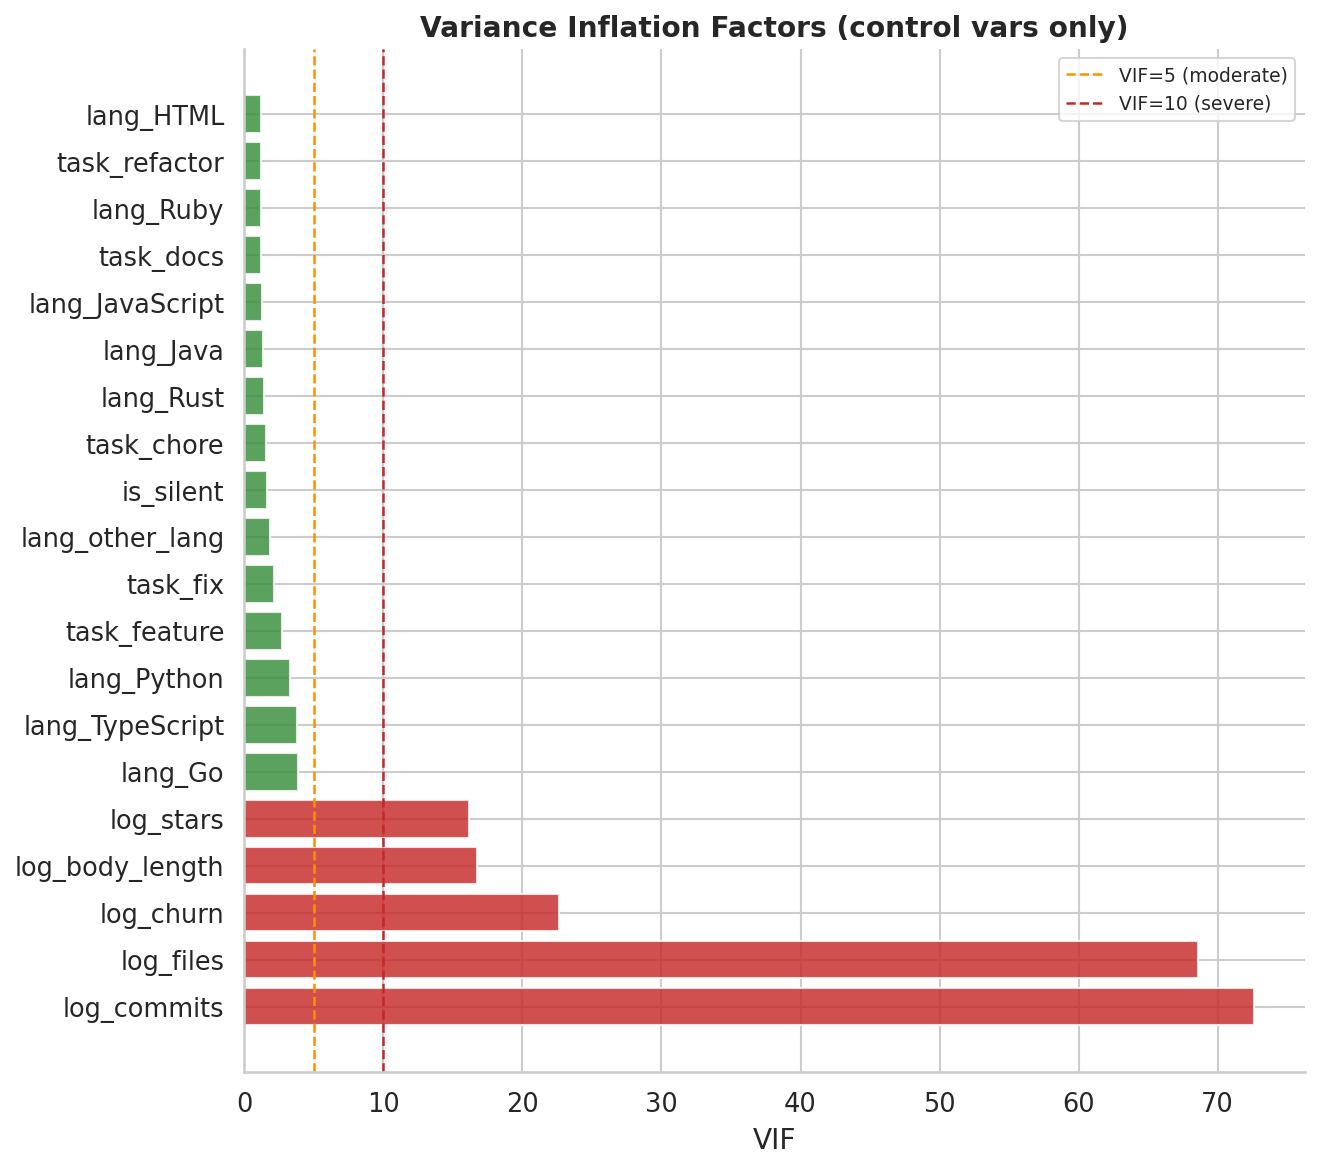

  ✓ outputs/fig4_ols_residuals.png


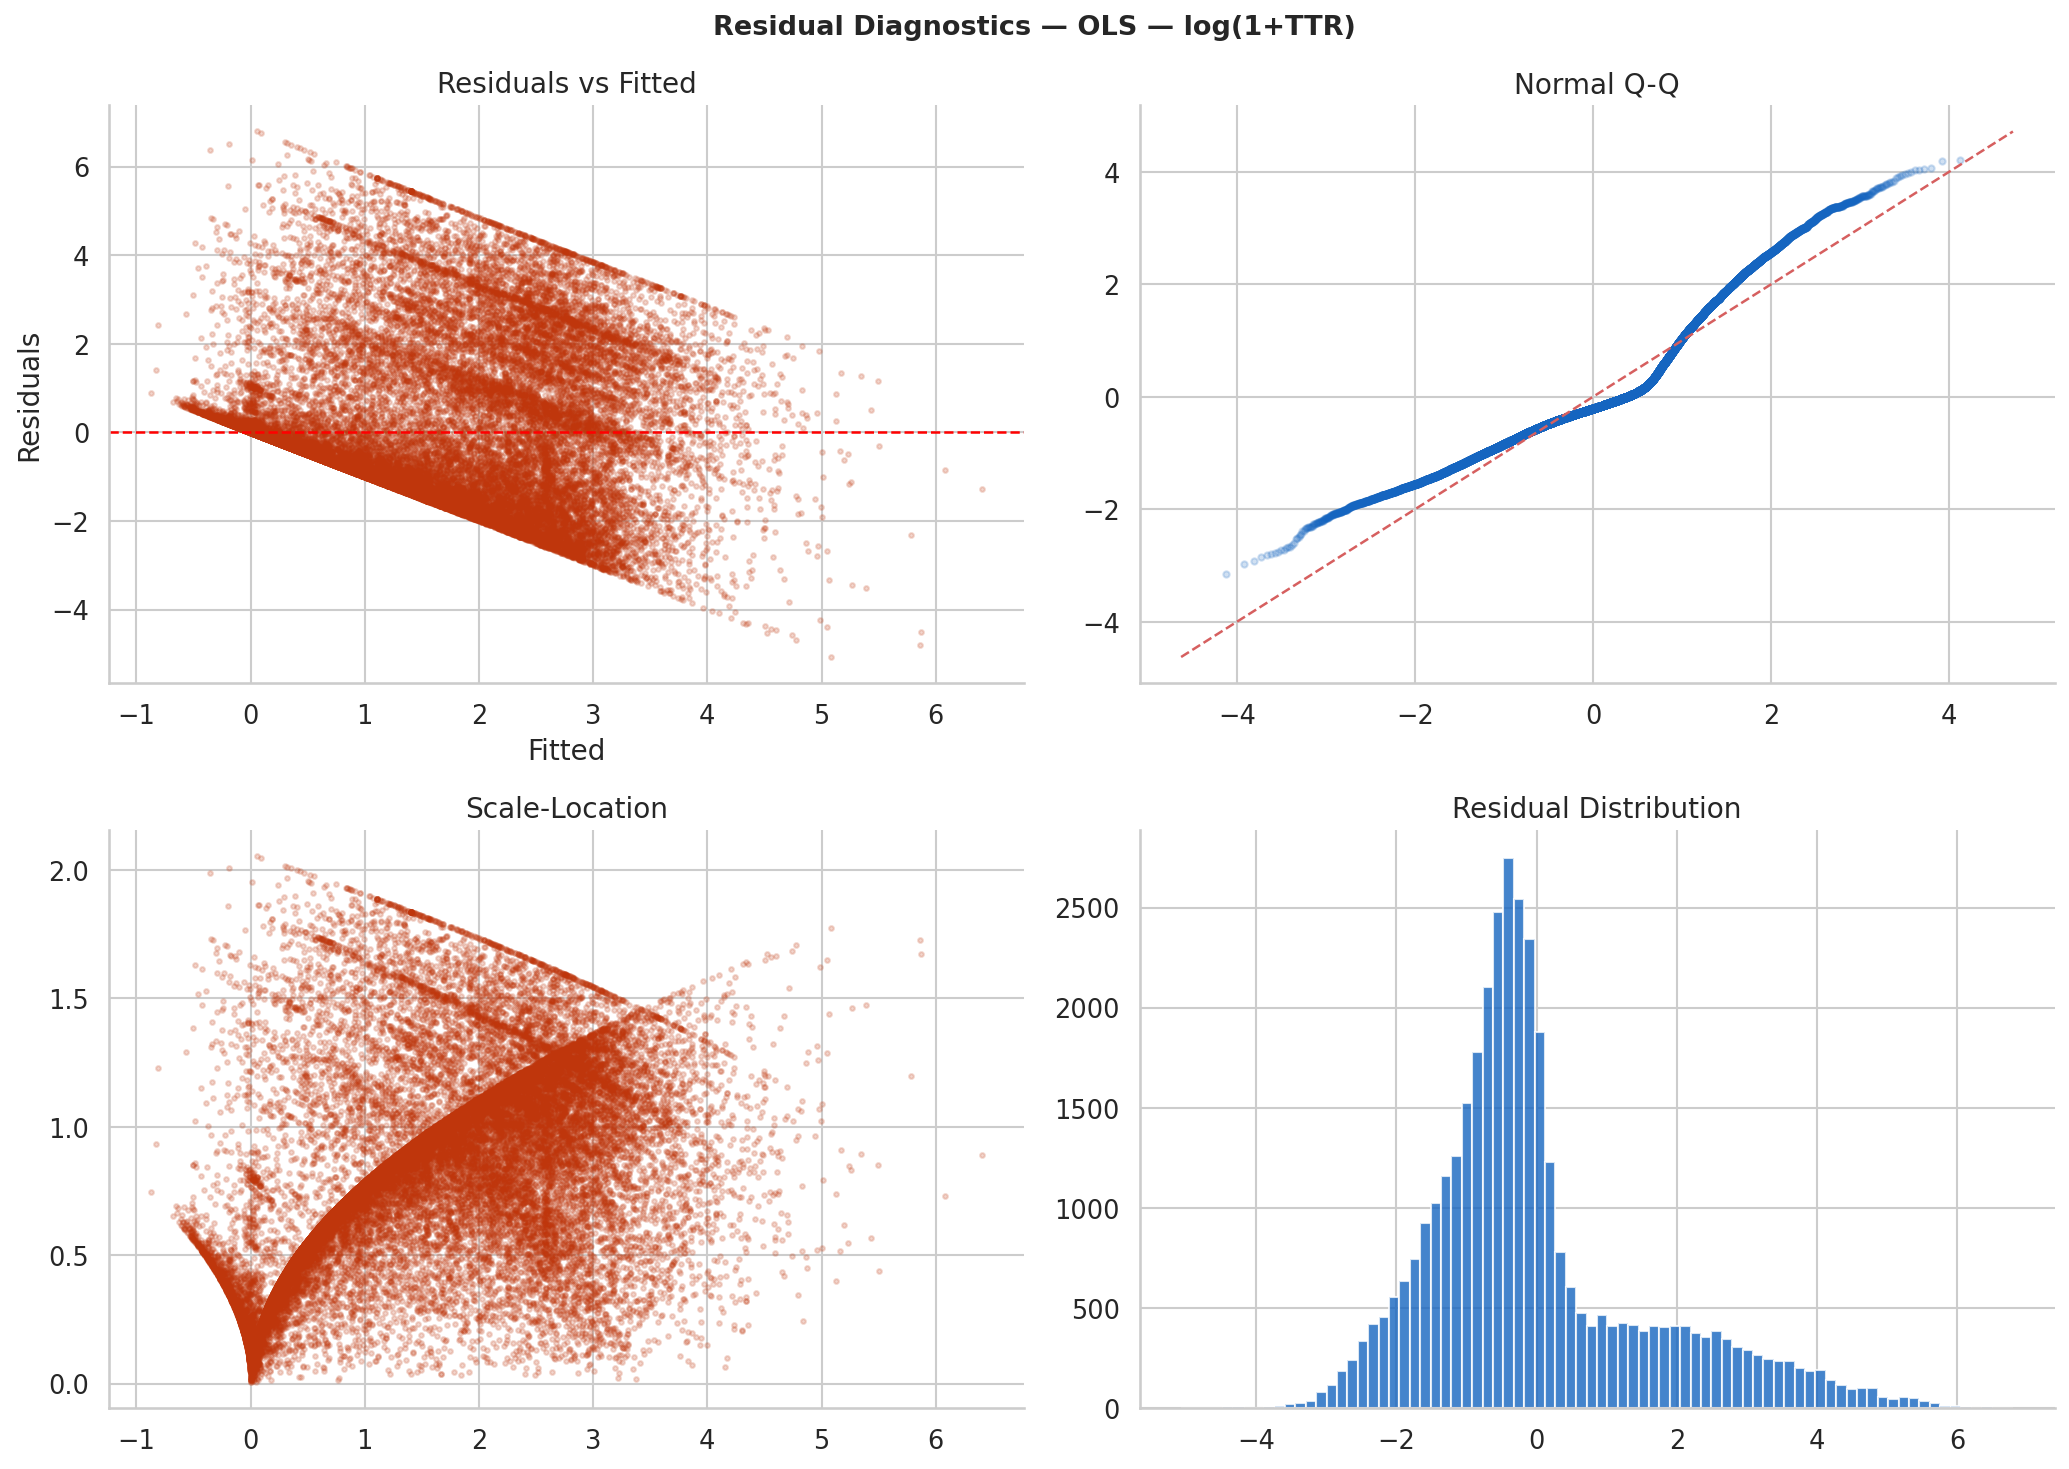

  ✓ outputs/fig5_ols_forest.png


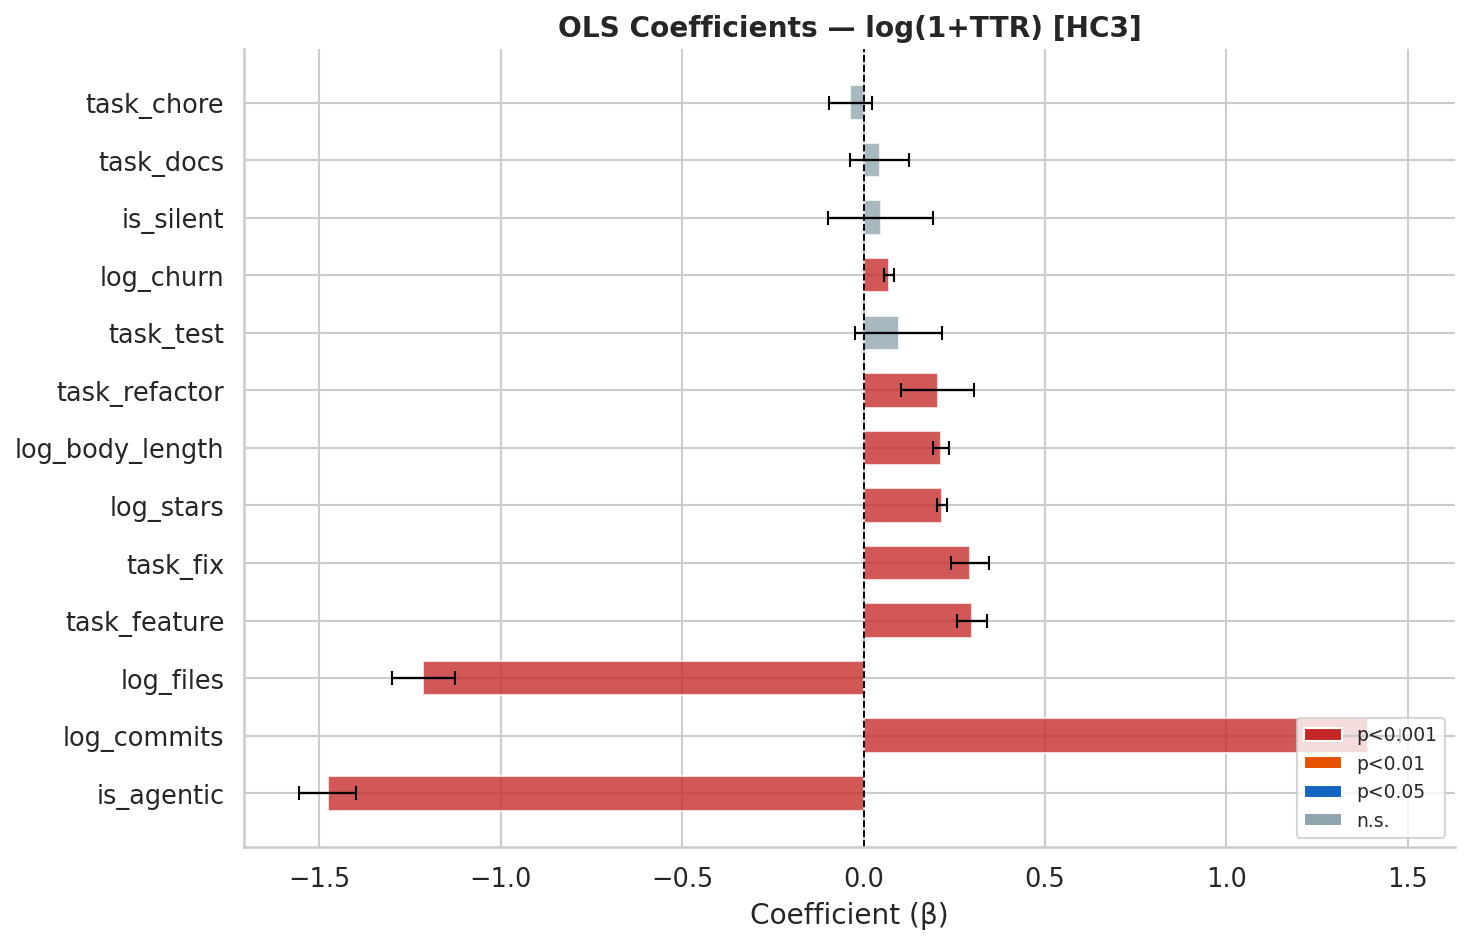

  ✓ outputs/fig6_logit_forest.png


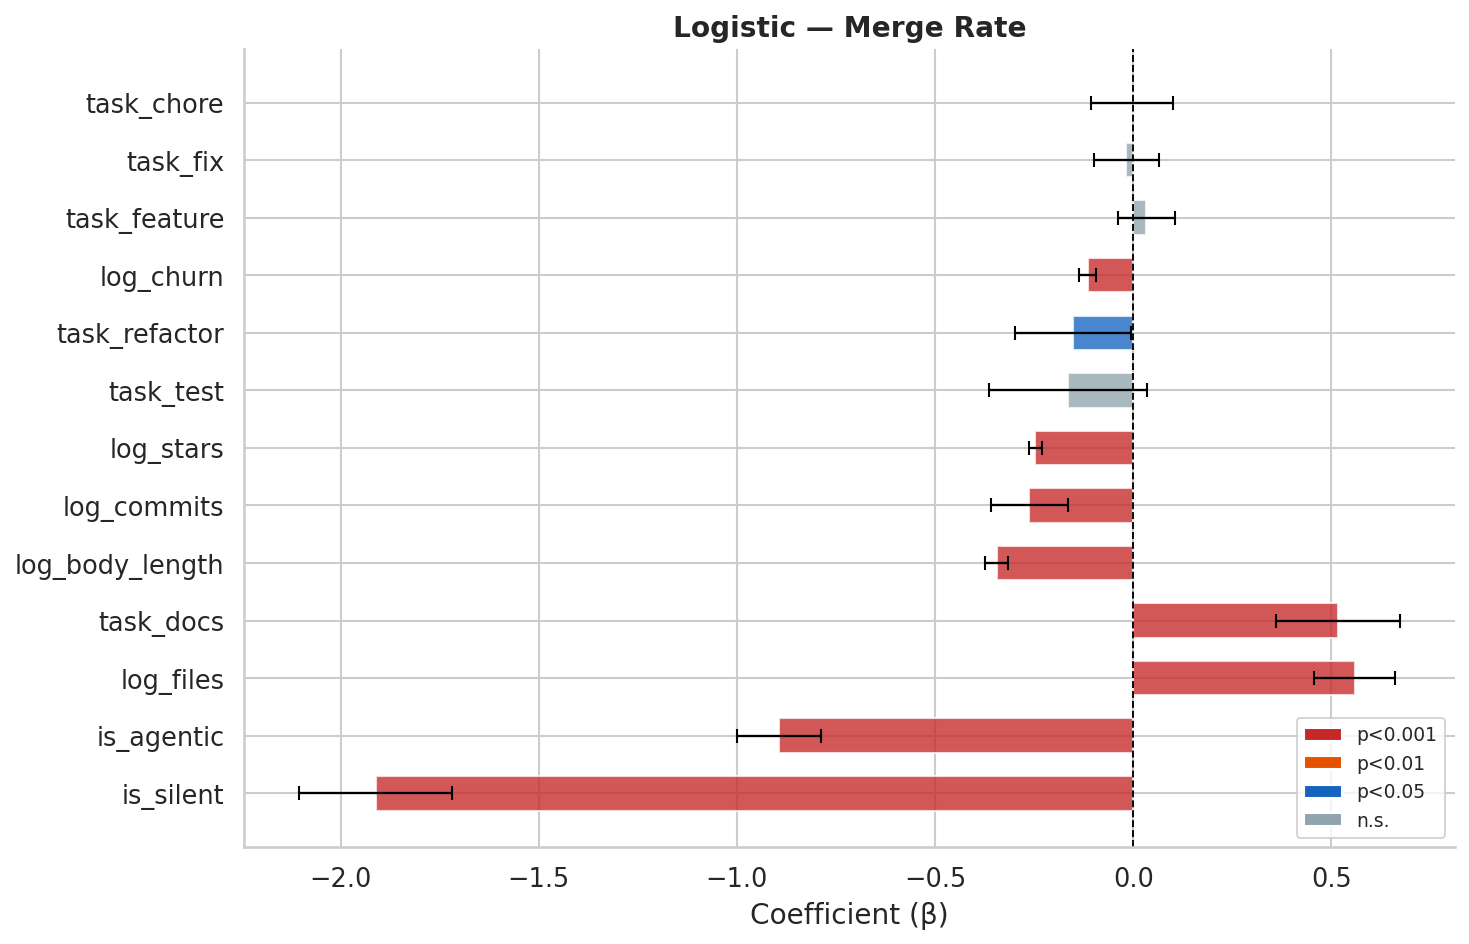

  ✓ outputs/fig7_agentic_diag.png


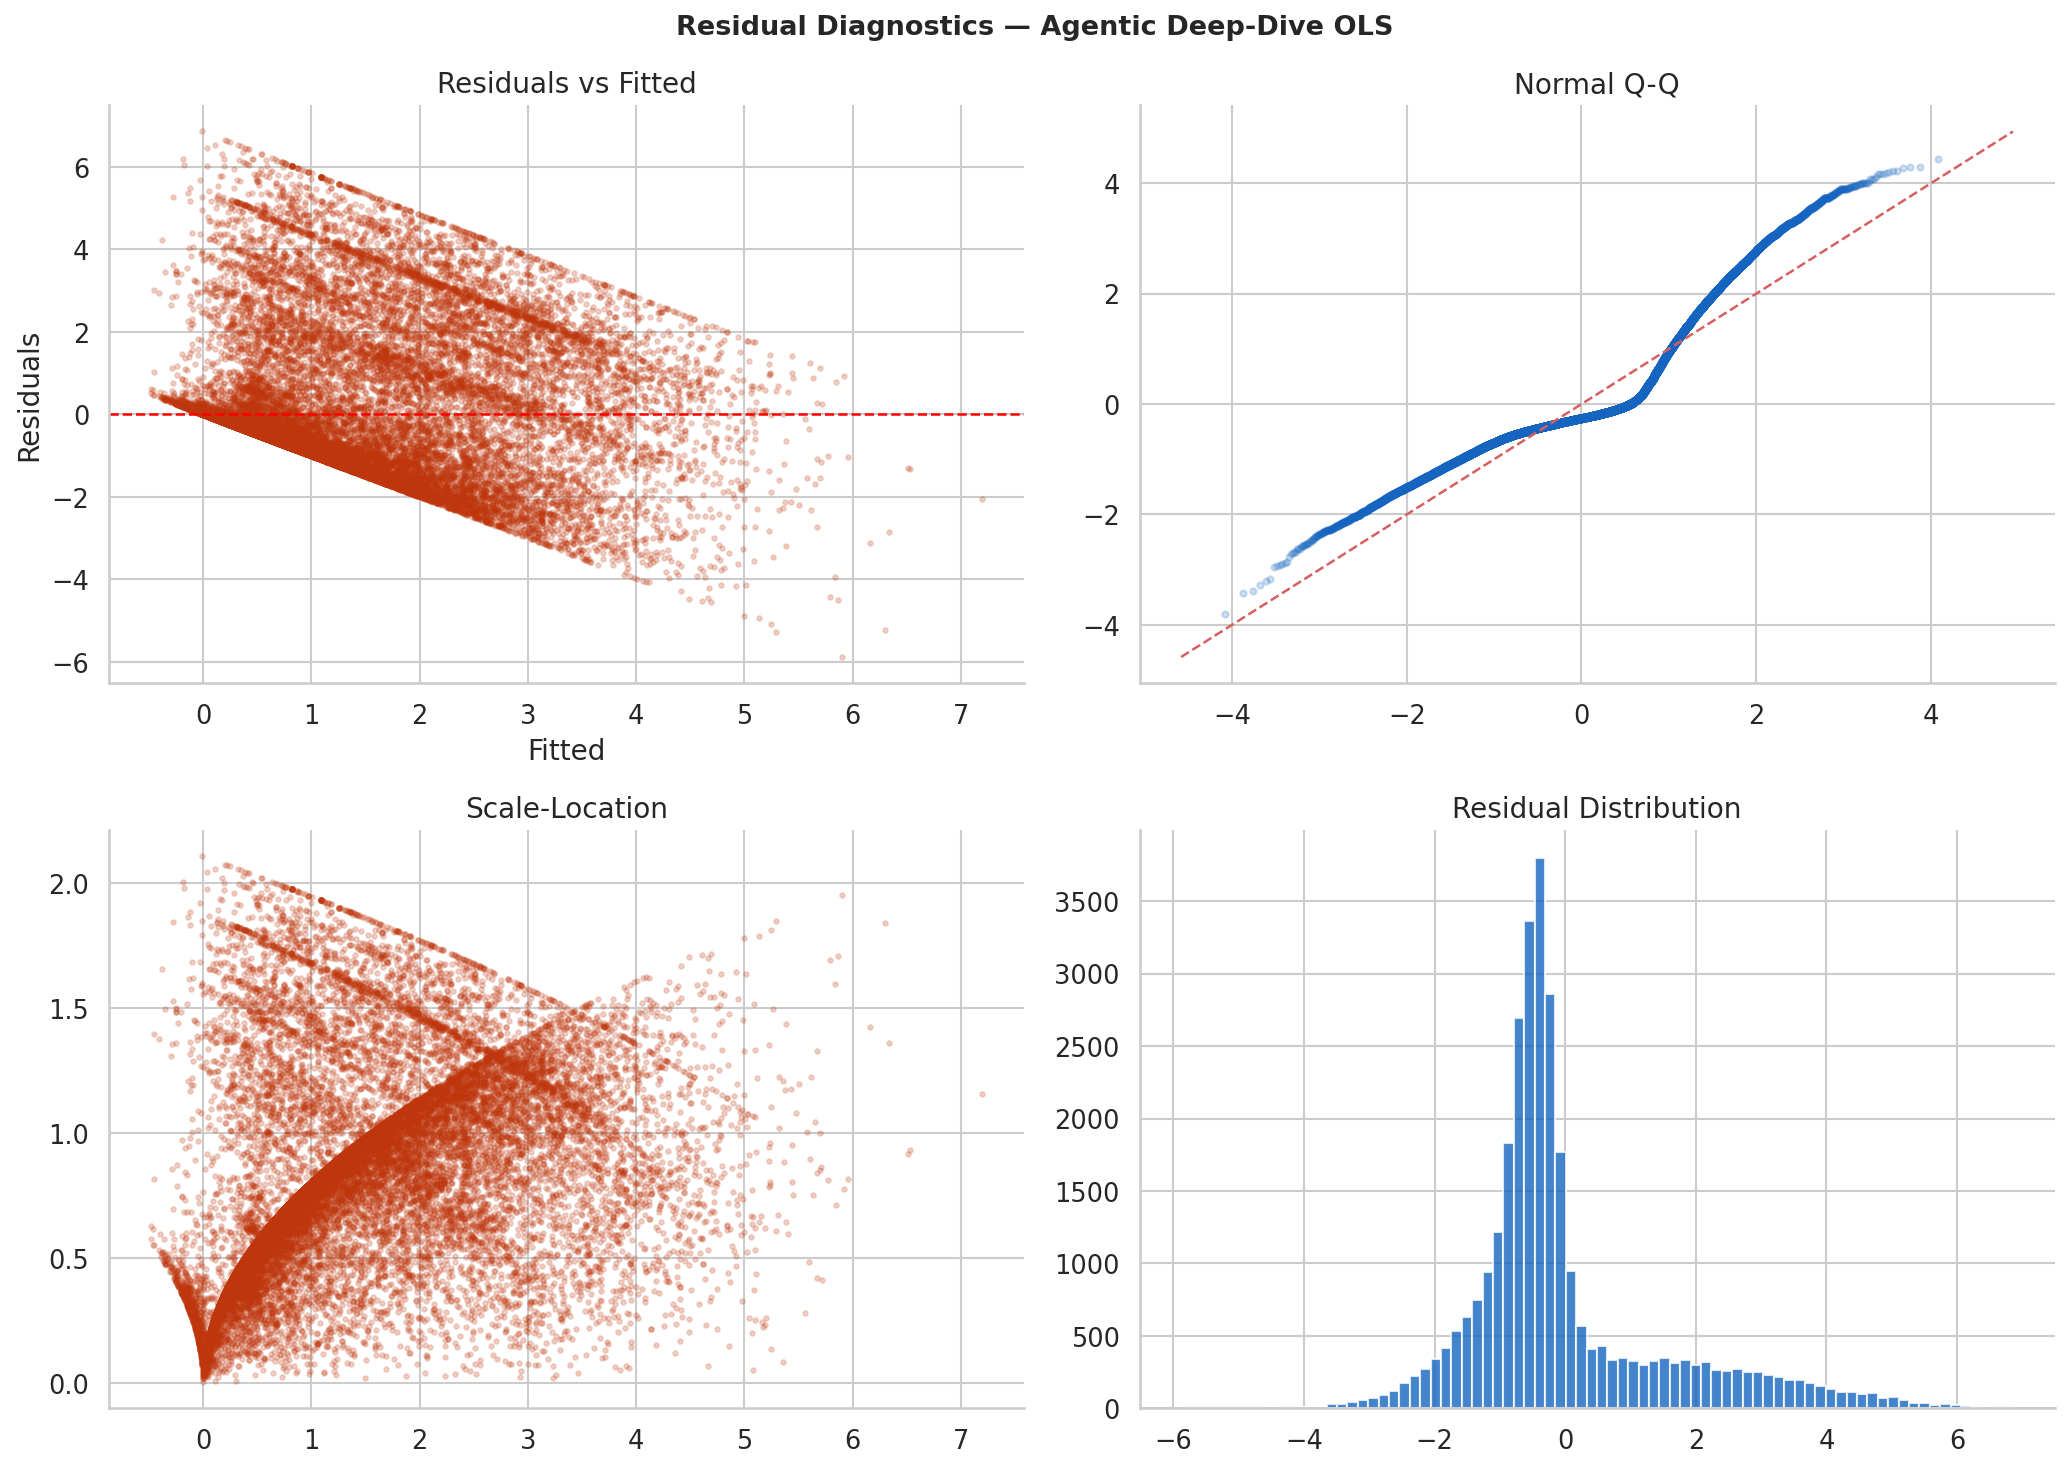

  ✓ outputs/fig8_agentic_forest.png


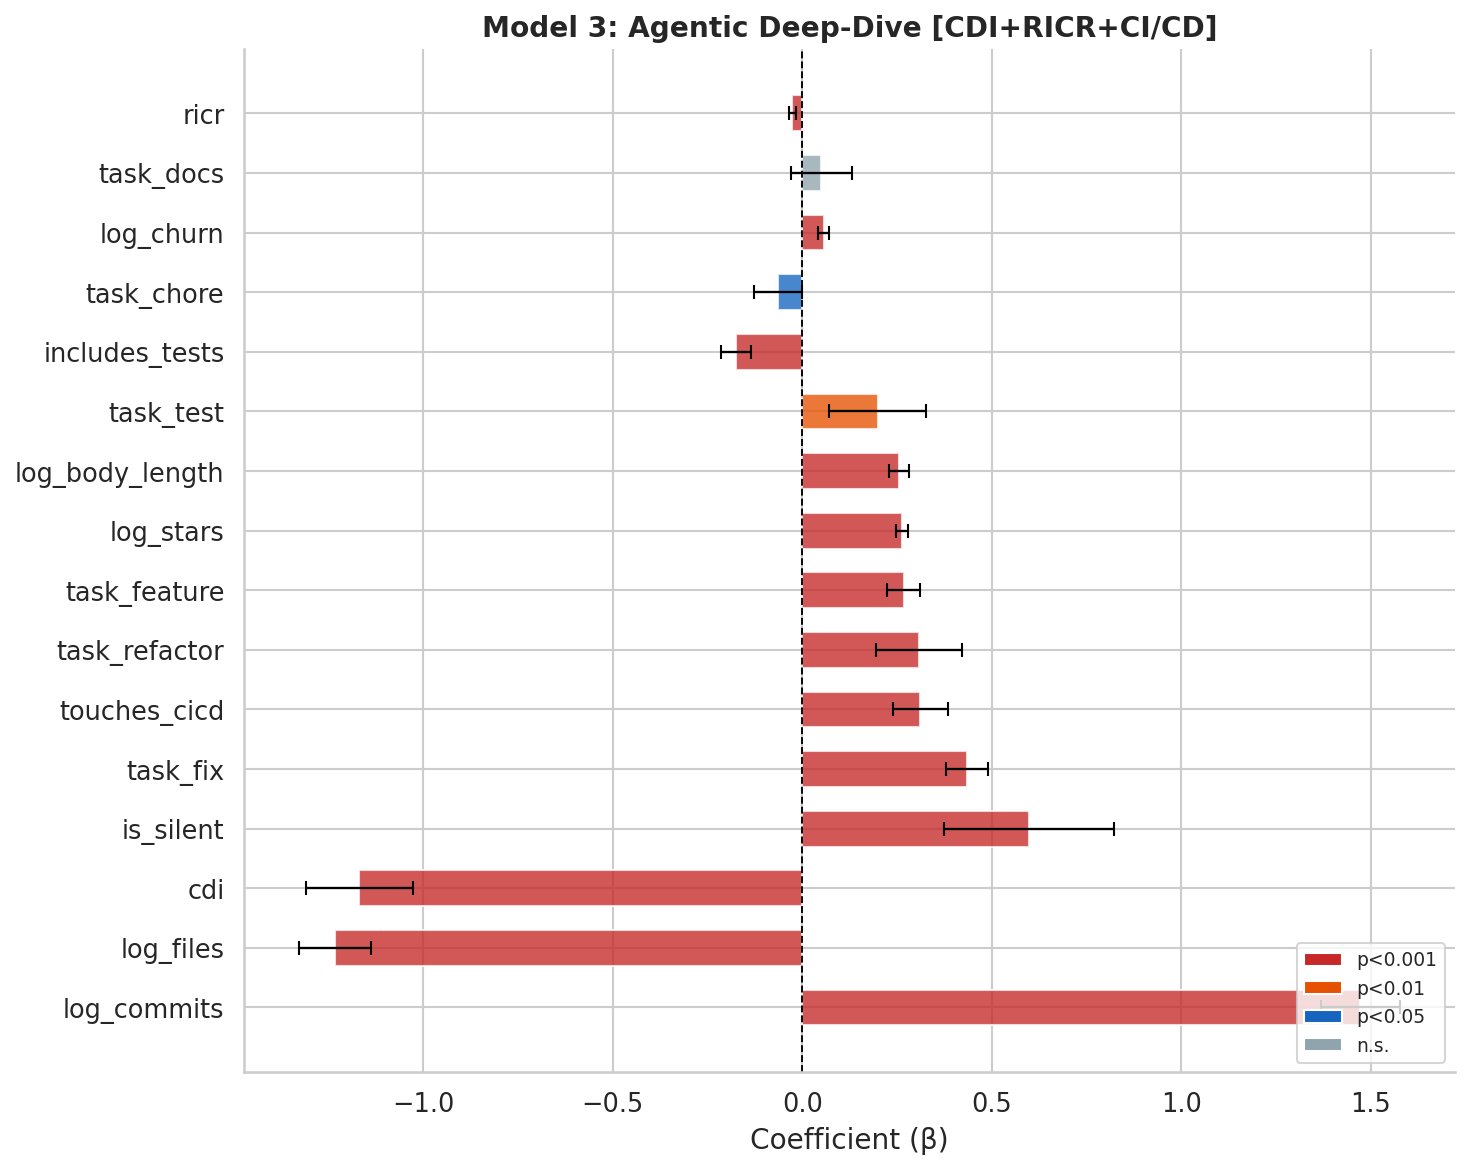

In [22]:
def fig_residuals(model, label: str, fname: str):
    """4-panel residual diagnostics: Residuals vs Fitted, Q-Q, Scale-Location, Histogram."""
    resid  = model.resid
    fitted = model.fittedvalues
    std_r  = (resid-resid.mean())/resid.std()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"Residual Diagnostics — {label}", fontsize=13, fontweight="bold")

    # Residuals vs Fitted: should show no pattern (random scatter around 0)
    axes[0,0].scatter(fitted, resid, alpha=0.2, s=5, color=_P[1])
    axes[0,0].axhline(0, color="red", lw=1.2, linestyle="--")
    axes[0,0].set_title("Residuals vs Fitted"); axes[0,0].set_xlabel("Fitted")
    axes[0,0].set_ylabel("Residuals")

    # Q-Q plot: points should follow the diagonal for normality
    osm, osr = stats.probplot(std_r, dist="norm", fit=False)
    lims = [min(osm[0],osr[0])-0.5, max(osm[-1],osr[-1])+0.5]
    axes[0,1].plot(osm, osr, "o", alpha=0.2, ms=3, color=_P[0])
    axes[0,1].plot(lims, lims, "r--", lw=1.2)
    axes[0,1].set_title("Normal Q-Q")

    # Scale-Location: √|std residuals| vs fitted — flat line = homoscedastic
    axes[1,0].scatter(fitted, np.sqrt(np.abs(std_r)), alpha=0.2, s=5, color=_P[1])
    axes[1,0].set_title("Scale-Location")

    # Residual histogram
    axes[1,1].hist(resid, bins=80, color=_P[0], edgecolor="white", alpha=0.8)
    axes[1,1].set_title("Residual Distribution")

    plt.tight_layout()
    p = OUTPUT_DIR / fname
    plt.savefig(p); print(f"  ✓ {p}"); plt.show()


def fig_forest(model, title: str, fname: str):
    """Coefficient forest plot — top 18 predictors by |β|. Language dummies hidden."""
    ci   = model.conf_int(); ci.columns = ["lo","hi"]
    df_c = pd.DataFrame({
        "Feature": model.params.index,
        "coef":    model.params.values,
        "lo":      ci["lo"].values,
        "hi":      ci["hi"].values,
        "p":       model.pvalues.values,
    })
    df_c = df_c[(df_c.Feature!="const") & ~df_c.Feature.str.startswith("lang_")]
    df_c["abs"] = df_c.coef.abs()
    df_c = df_c.nlargest(18, "abs")
    df_c["sig"] = pd.cut(df_c.p, [0,0.001,0.01,0.05,1.],
                         labels=["p<0.001","p<0.01","p<0.05","n.s."])
    sc = {"p<0.001":"#C62828","p<0.01":"#E65100","p<0.05":"#1565C0","n.s.":"#90A4AE"}

    fig, ax = plt.subplots(figsize=(10, max(5, len(df_c)*0.5)))
    for _, row in df_c.iterrows():
        c = sc.get(str(row.sig),"#90A4AE")
        ax.barh(row.Feature, row.coef, color=c, alpha=0.78, height=0.6)
        ax.errorbar(row.coef, row.Feature,
                    xerr=[[row.coef-row.lo],[row.hi-row.coef]],
                    fmt="none", color="black", capsize=3.5, lw=1.1)
    ax.axvline(0, color="black", lw=0.9, linestyle="--")
    ax.set_xlabel("Coefficient (β)")
    ax.set_title(title, fontweight="bold")
    ax.legend(handles=[Patch(facecolor=c,label=l) for l,c in sc.items()],
              loc="lower right", fontsize=9)
    plt.tight_layout()
    p = OUTPUT_DIR / fname
    plt.savefig(p); print(f"  ✓ {p}"); plt.show()


def fig_vif(vif_df: pd.DataFrame, fname: str):
    """VIF bar chart with colour-coded thresholds."""
    fig, ax = plt.subplots(figsize=(9, max(4, len(vif_df)*0.4)))
    colors = vif_df.VIF.apply(
        lambda v: "#C62828" if v>10 else ("#FF8F00" if v>5 else "#388E3C"))
    ax.barh(vif_df.Feature, vif_df.VIF, color=colors, alpha=0.82)
    ax.axvline(5,  color="#FF8F00", lw=1.2, linestyle="--", label="VIF=5 (moderate)")
    ax.axvline(10, color="#C62828", lw=1.2, linestyle="--", label="VIF=10 (severe)")
    ax.set_xlabel("VIF")
    ax.set_title("Variance Inflation Factors (control vars only)", fontweight="bold")
    ax.legend(fontsize=9)
    plt.tight_layout()
    p = OUTPUT_DIR / fname
    plt.savefig(p); print(f"  ✓ {p}"); plt.show()

fig_vif(vif_df.head(20), "fig3_vif.png")
fig_residuals(ols_m, "OLS — log(1+TTR)", "fig4_ols_residuals.png")
fig_forest(ols_m, "OLS Coefficients — log(1+TTR) [HC3]", "fig5_ols_forest.png")

if logit_m is not None:
    fig_forest(logit_m, "Logistic — Merge Rate", "fig6_logit_forest.png")

fig_residuals(ag_m, "Agentic Deep-Dive OLS", "fig7_agentic_diag.png")
fig_forest(ag_m, "Model 3: Agentic Deep-Dive [CDI+RICR+CI/CD]", "fig8_agentic_forest.png")

In [23]:
    # Build flow: Author → Task → Outcome
    task_cols = [c for c in df.columns if c.startswith('task_')]
    df2 = df.copy()
    if task_cols:
        def get_task_label(row):
            vals = pd.to_numeric(row[task_cols], errors='coerce').fillna(0)
            max_idx = vals.idxmax()
            max_val = vals.max()
            if max_val > 0:
                return max_idx.replace('task_', '')
            return 'other'

        df2['task_label'] = df2.apply(get_task_label, axis=1)
    else:
        df2['task_label'] = 'other'

  Fitting quantile regression across τ ∈ [0.1 … 0.9] ...
    τ=0.10  β=-0.0750  95%CI=[-0.0835, -0.0666]
    τ=0.20  β=-0.2308  95%CI=[-0.2413, -0.2204]
    τ=0.30  β=-0.4914  95%CI=[-0.5033, -0.4794]
    τ=0.40  β=-0.7944  95%CI=[-0.8069, -0.7820]
    τ=0.50  β=-1.0941  95%CI=[-1.1074, -1.0807]
    τ=0.60  β=-1.3934  95%CI=[-1.4141, -1.3726]


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


    τ=0.70  β=-1.7305  95%CI=[-1.7699, -1.6912]
    τ=0.80  β=-2.1434  95%CI=[-2.2104, -2.0764]
    τ=0.90  β=-2.1610  95%CI=[-2.3267, -1.9954]

  ✓ outputs/fig10_quantile_regression.png


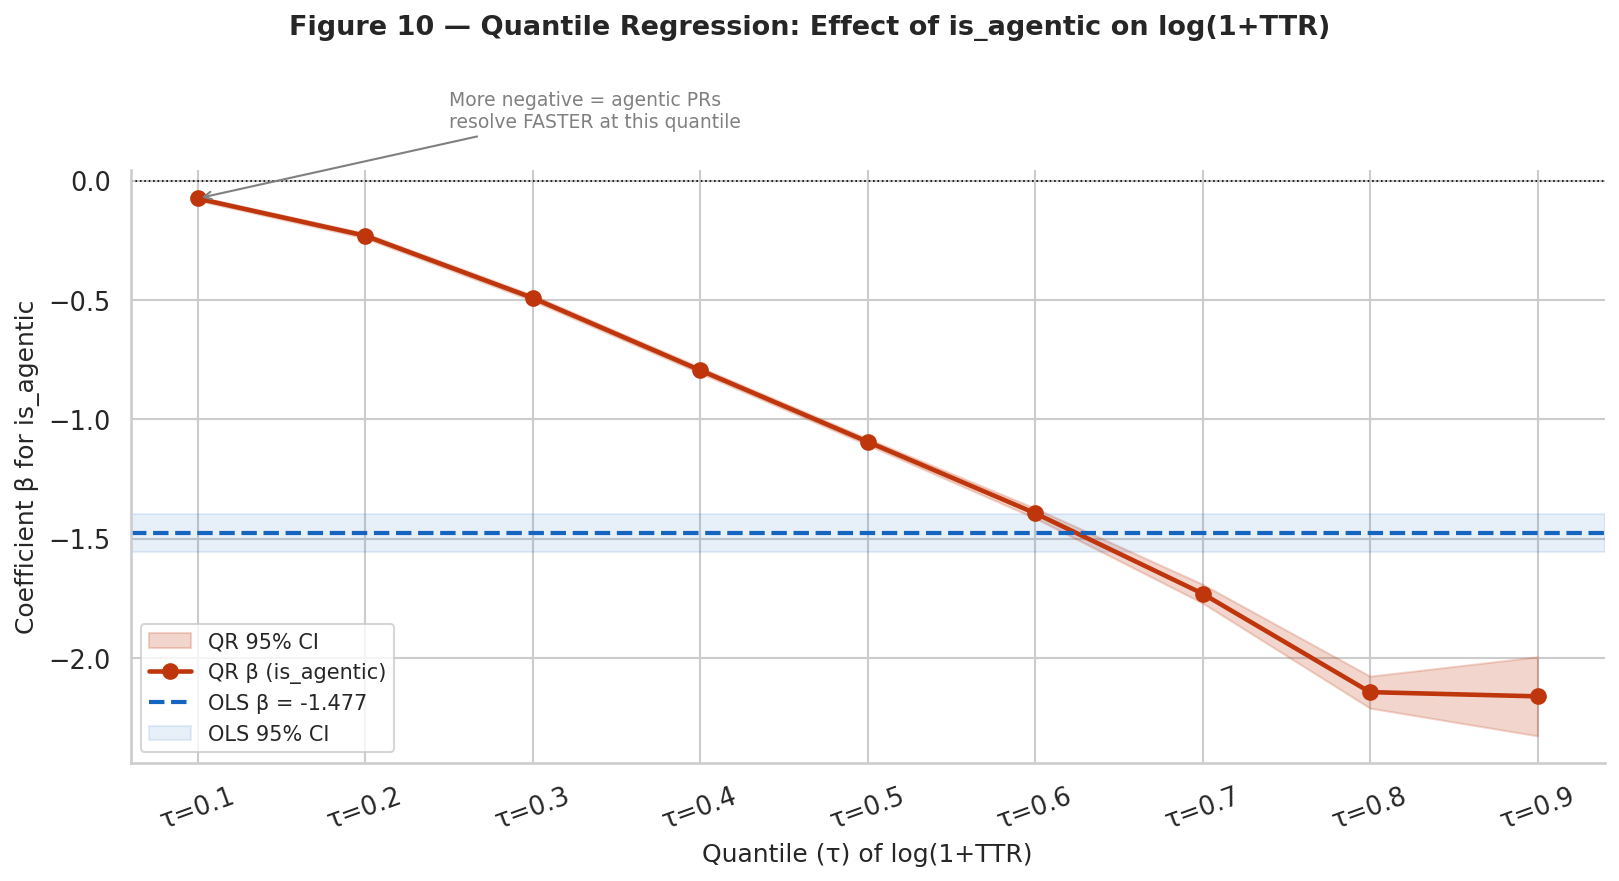

In [24]:
# ── Fig 10: Quantile Regression Plot
def fig10_quantile_regression(df: pd.DataFrame, ols_model):
    from statsmodels.regression.quantile_regression import QuantReg

    cols = [c for c in ols_model.params.index if c != 'const']
    X    = sm.add_constant(df[cols].astype(float))
    y    = df['log_ttr'].astype(float)
    mask = X.notna().all(1) & y.notna()
    X_m, y_m = X[mask], y[mask]

    quantiles  = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]
    betas, cis = [], []

    print('  Fitting quantile regression across τ ∈ [0.1 … 0.9] ...')
    qr_model = QuantReg(y_m, X_m)
    for q in quantiles:
        res = qr_model.fit(q=q, vcov='robust', bandwidth='hsheather', kernel='epa')
        b   = res.params.get('is_agentic', np.nan)
        ci  = res.conf_int()
        lo  = ci.loc['is_agentic', 0] if 'is_agentic' in ci.index else np.nan
        hi  = ci.loc['is_agentic', 1] if 'is_agentic' in ci.index else np.nan
        betas.append(b)
        cis.append((lo, hi))
        print(f'    τ={q:.2f}  β={b:+.4f}  95%CI=[{lo:+.4f}, {hi:+.4f}]')

    # OLS reference
    ols_b  = ols_model.params.get('is_agentic', np.nan)
    ols_lo = ols_model.conf_int().loc['is_agentic', 0]
    ols_hi = ols_model.conf_int().loc['is_agentic', 1]

    # Plot
    fig, ax = plt.subplots(figsize=(11, 6))
    fig.suptitle('Figure 10 — Quantile Regression: Effect of is_agentic on log(1+TTR)',
                 fontsize=13, fontweight='bold')

    lo_arr = np.array([c[0] for c in cis])
    hi_arr = np.array([c[1] for c in cis])

    ax.fill_between(quantiles, lo_arr, hi_arr, alpha=0.20, color='#BF360C', label='QR 95% CI')
    ax.plot(quantiles, betas, 'o-', color='#BF360C', lw=2.2, ms=7, label='QR β (is_agentic)')

    # OLS reference band
    ax.axhline(ols_b,  color='#1565C0', lw=2, linestyle='--', label=f'OLS β = {ols_b:.3f}')
    ax.axhspan(ols_lo, ols_hi, alpha=0.10, color='#1565C0', label='OLS 95% CI')
    ax.axhline(0, color='black', lw=0.8, linestyle=':')

    ax.set_xlabel('Quantile (τ) of log(1+TTR)', fontsize=12)
    ax.set_ylabel('Coefficient β for is_agentic', fontsize=12)
    ax.set_xticks(quantiles)
    ax.set_xticklabels([f'τ={q}' for q in quantiles], rotation=20)
    ax.legend(fontsize=10)

    # Annotation
    ax.annotate('More negative = agentic PRs\nresolve FASTER at this quantile',
                xy=(0.10, betas[0]), xytext=(0.25, betas[0]+0.3),
                arrowprops=dict(arrowstyle='->', color='gray'),
                fontsize=9, color='gray')

    plt.tight_layout()
    p = OUTPUT_DIR / 'fig10_quantile_regression.png'
    plt.savefig(p); print(f'\n  ✓ {p}'); plt.show()


fig10_quantile_regression(df, ols_m)

  ✓ outputs/fig11_corr_network.png


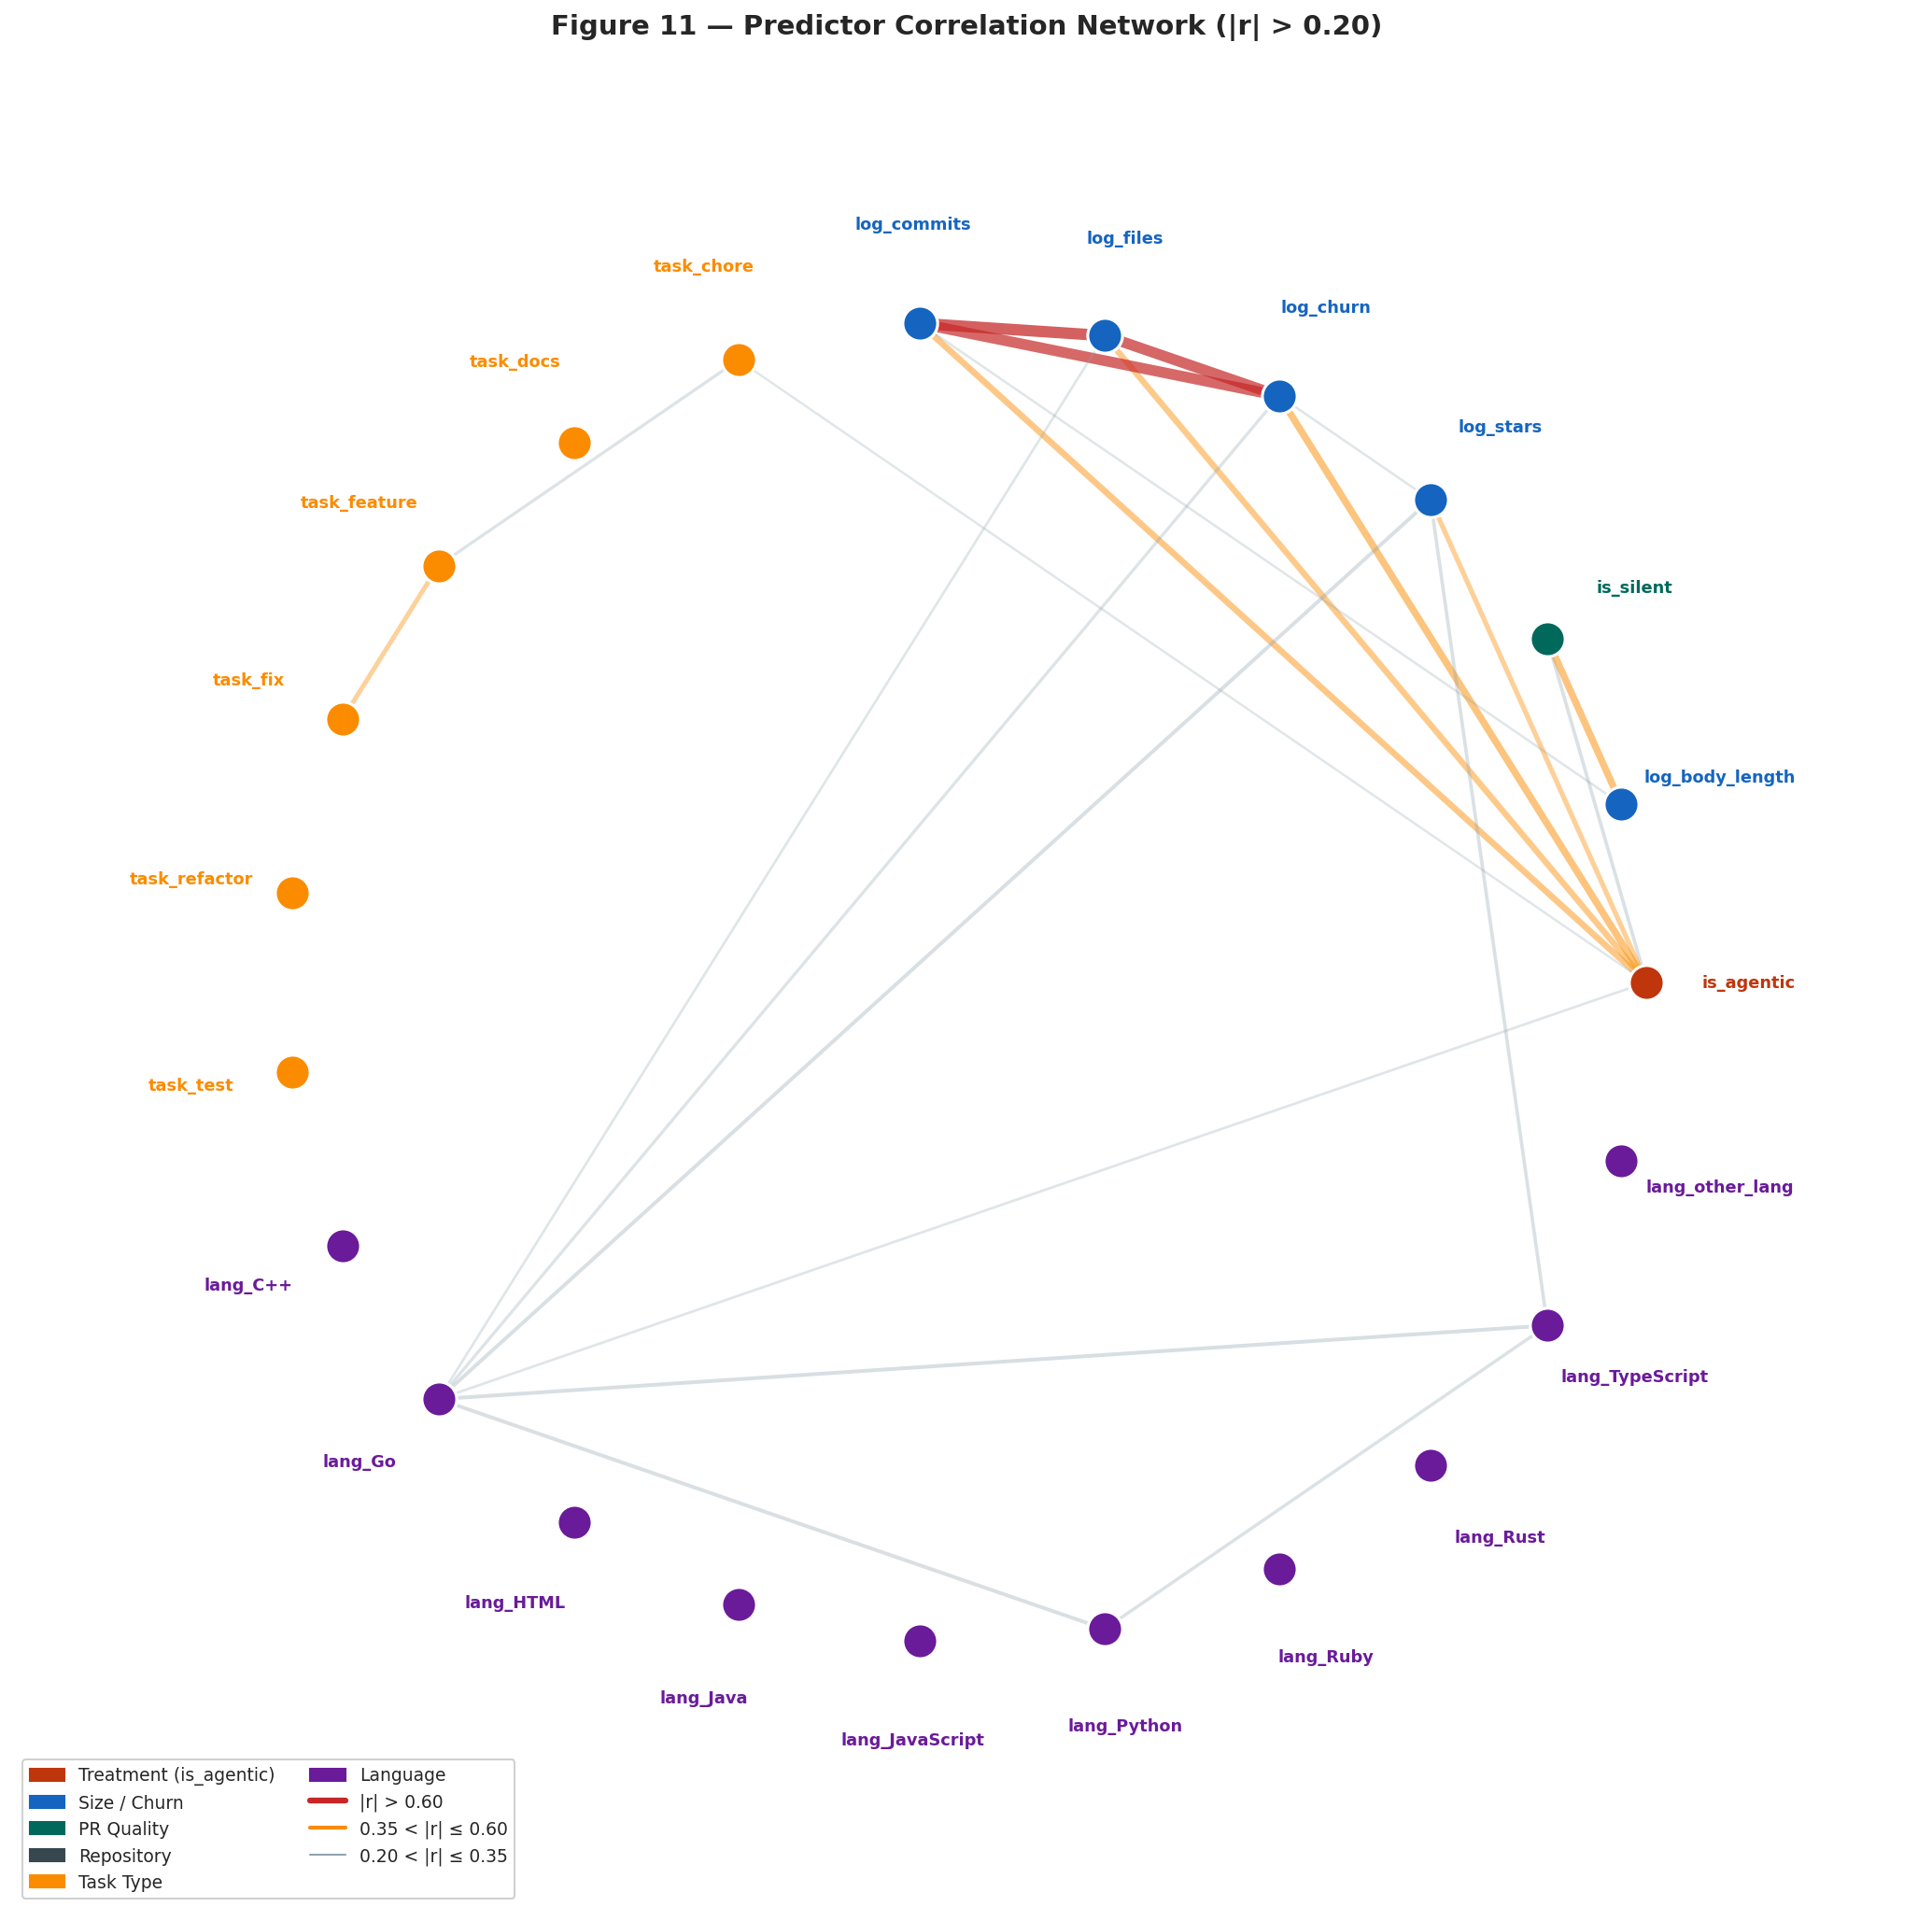

In [25]:
# ── Fig 11: Correlation Network Graph
def fig11_corr_network(df: pd.DataFrame, ols_cols: list):
    import matplotlib.patches as mpatches
    from itertools import combinations

    # Use only the actual predictor columns
    feat_cols = [c for c in ols_cols if c in df.columns]
    corr = df[feat_cols].corr().abs()
    # Threshold: only show edges where |r| > 0.20
    THRESH = 0.20
    edges = []
    for a, b in combinations(feat_cols, 2):
        r = corr.loc[a, b]
        if r > THRESH:
            edges.append((a, b, float(r)))
    def node_color(n):
        if n == 'is_agentic':           return '#BF360C'
        if n.startswith('log_'):        return '#1565C0'
        if n.startswith('task_'):       return '#FB8C00'
        if n.startswith('lang_'):       return '#6A1B9A'
        if n in ['is_silent','log_body_length']: return '#00695C'
        if n == 'log_stars':            return '#37474F'
        return '#78909C'

    n = len(feat_cols)
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    pos = {node: (np.cos(a), np.sin(a)) for node, a in zip(feat_cols, angles)}

    fig, ax = plt.subplots(figsize=(14, 14))
    fig.suptitle('Figure 11 — Predictor Correlation Network (|r| > 0.20)',
                 fontsize=14, fontweight='bold')

    # Draw edges
    for a, b, r in edges:
        x0, y0 = pos[a]; x1, y1 = pos[b]
        lw    = r * 6
        alpha = 0.15 + r * 0.6
        color = '#C62828' if r > 0.6 else ('#FB8C00' if r > 0.35 else '#90A4AE')
        ax.plot([x0, x1], [y0, y1], color=color, lw=lw, alpha=alpha, zorder=1)

    # Draw nodes
    for node, (x, y) in pos.items():
        c = node_color(node)
        ax.scatter(x, y, s=320, color=c, zorder=3, edgecolors='white', linewidths=1.5)
        # Label offset slightly outward
        offset = 1.15
        ax.text(x * offset, y * offset, node,
                ha='center', va='center', fontsize=8.5, fontweight='bold',
                color=c, zorder=4)

    # Legend
    legend_items = [
        mpatches.Patch(color='#BF360C', label='Treatment (is_agentic)'),
        mpatches.Patch(color='#1565C0', label='Size / Churn'),
        mpatches.Patch(color='#00695C', label='PR Quality'),
        mpatches.Patch(color='#37474F', label='Repository'),
        mpatches.Patch(color='#FB8C00', label='Task Type'),
        mpatches.Patch(color='#6A1B9A', label='Language'),
        plt.Line2D([0],[0], color='#C62828', lw=3, label='|r| > 0.60'),
        plt.Line2D([0],[0], color='#FB8C00', lw=2, label='0.35 < |r| ≤ 0.60'),
        plt.Line2D([0],[0], color='#90A4AE', lw=1, label='0.20 < |r| ≤ 0.35'),
    ]
    ax.legend(handles=legend_items, loc='lower left', fontsize=9,
              framealpha=0.9, ncol=2)
    ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4)
    ax.axis('off')
    plt.tight_layout()
    p = OUTPUT_DIR / 'fig11_corr_network.png'
    plt.savefig(p, dpi=160); print(f'  ✓ {p}'); plt.show()


fig11_corr_network(df, ols_cols)

---
## Block 9 — RESULTS SUMMARY

In [26]:
def print_short_results(ols_m, logit_m, ag_m, hyp, restricted_r2=0.0):
    ag_b = ols_m.params.get("is_agentic", np.nan)
    ag_p = ols_m.pvalues.get("is_agentic", np.nan)

    if logit_m is not None:
        OR   = np.exp(logit_m.params.get("is_agentic", np.nan))
        OR_p = logit_m.pvalues.get("is_agentic", np.nan)
        logit_str = f"OR={OR:.3f}, p={OR_p:.4f}"
    else:
        logit_str = "Logit skipped"

    delta_r2 = ols_m.rsquared - restricted_r2

    print("\n=== RESULTS SUMMARY ===")

    print(f"OLS (TTR): β={ag_b:.4f}, p={ag_p:.4f}, R²={ols_m.rsquared:.3f}, ΔR²={delta_r2:.3f}")

    print(f"Logistic (Merge): {logit_str}")

    print(f"""Agentic OLS:
    CDI β={ag_m.params.get('cdi', np.nan):.4f}, p={ag_m.pvalues.get('cdi', np.nan):.4f}
    RICR β={ag_m.params.get('ricr', np.nan):.4f}, p={ag_m.pvalues.get('ricr', np.nan):.4f}
    CI/CD β={ag_m.params.get('touches_cicd', np.nan):.4f}, p={ag_m.pvalues.get('touches_cicd', np.nan):.4f}
    Tests β={ag_m.params.get('includes_tests', np.nan):.4f}, p={ag_m.pvalues.get('includes_tests', np.nan):.4f}
    """)

    print(f"T-test: t={hyp['t']:.3f}, p={hyp['p1']:.6f}")
    print(f"Mann-Whitney: r={hyp['r_mwu']:.3f}, p={hyp['p_mwu']:.6f}")

In [27]:
print_short_results(ols_m, logit_m, ag_m, hyp, restricted_r2=m_r.rsquared)


=== RESULTS SUMMARY ===
OLS (TTR): β=-1.4769, p=0.0000, R²=0.315, ΔR²=0.272
Logistic (Merge): OR=0.409, p=0.0000
Agentic OLS:
    CDI β=-1.1687, p=0.0000
    RICR β=-0.0266, p=0.0000
    CI/CD β=0.3117, p=0.0000
    Tests β=-0.1747, p=0.0000
    
T-test: t=-38.669, p=0.000000
Mann-Whitney: r=0.423, p=0.000000
